In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Initialize strict corporate style guidelines
CORPORATE_PALETTE = ['#1f4e79', '#2e75b6', '#bdd7ee', '#ffc000', '#ed7d31']
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.5
sns.set_palette(CORPORATE_PALETTE)

# Task 2: Marketing Uplift & Controlled Market Trial Simulation
## Step 1: Pre-Trial Operational Profiling & Performance Metrics Extraction

### Business & Strategic Rationale
To measure the financial revenue performance and commercial impact of an in-store layout test executed between February 2019 and April 2019 (Trial Stores: 77, 86, and 88), we establish a baseline pre-trial profile. This pipeline pulls raw transactional records, isolates the historical pre-trial window (July 2018 to January 2019), and calculates core monthly tracking metrics to find matching control store pairs.


In [18]:
# Ingest pre-merged retail data core
df = pd.read_csv("QVI_data.csv")
df["DATE"] = pd.to_datetime(df["DATE"])

# Structural profile baseline check
print(f"Total Unique Retail Store Footprint: {df['STORE_NBR'].nunique()}")

# Structure the categorical Year-Month chronological field
df_full_year = df.copy()
df_full_year["YEAR_MONTH"] = df_full_year["DATE"].dt.to_period('M')
df_full_year = df_full_year.sort_values(by="YEAR_MONTH")

# Isolate historical pre-trial operation timeframe baseline (7-Month window)
pre_trial_months = pd.date_range(start='2018-07-01', end='2019-01-31', freq='MS').to_period('M')
df_pre_trial = df_full_year[df_full_year["YEAR_MONTH"].isin(pre_trial_months)].copy()

print(f"Pre-Trial Baseline Data Constraints: {df_pre_trial['YEAR_MONTH'].unique()}")

Total Unique Retail Store Footprint: 271
Pre-Trial Baseline Data Constraints: <PeriodArray>
['2018-07', '2018-08', '2018-09', '2018-10', '2018-11', '2018-12', '2019-01']
Length: 7, dtype: period[M]


## Unified Multi-Metric Aggregation Pipeline
### Technical Optimization
Instead of querying separate `groupby` passes, this unified pipeline extracts absolute total sales, unique customer footprints, transaction counts, and product volumes in a single execution step to maximize speed and prevent data fragmentation.


In [19]:
# Construct standardized monthly store tracking parameters
store_monthly_metrics = df_pre_trial.groupby(["STORE_NBR", "YEAR_MONTH"]).agg(
    TOT_SALES=('TOT_SALES', 'sum'),
    UNIQUE_CUSTOMERS=('LYLTY_CARD_NBR', 'nunique'),
    TOTAL_TRANSACTIONS=('TXN_ID', 'nunique'),
    TOTAL_QTY=('PROD_QTY', 'sum')
).reset_index()

# Derive advanced behavioral category indexes
store_monthly_metrics["TXN_PER_CUST"] = store_monthly_metrics["TOTAL_TRANSACTIONS"] / store_monthly_metrics["UNIQUE_CUSTOMERS"]
store_monthly_metrics["CHIPS_PER_CUST"] = store_monthly_metrics["TOTAL_QTY"] / store_monthly_metrics["UNIQUE_CUSTOMERS"]
store_monthly_metrics["AVG_PRICE_PER_UNIT"] = store_monthly_metrics["TOT_SALES"] / store_monthly_metrics["TOTAL_QTY"]

# Sort operational arrays chronologically
store_monthly_metrics = store_monthly_metrics.sort_values(by=["STORE_NBR", "YEAR_MONTH"])

## Pre-Trial Visual Core: Trend Analysis for Target Trial Stores
### Operational Insights
Below, we visualize the core tracking trends for our designated Trial Locations (Stores 77, 86, and 88). These visual benchmarks track sales density, unique foot traffic, transaction frequency, and pricing structures before the test layout launched.


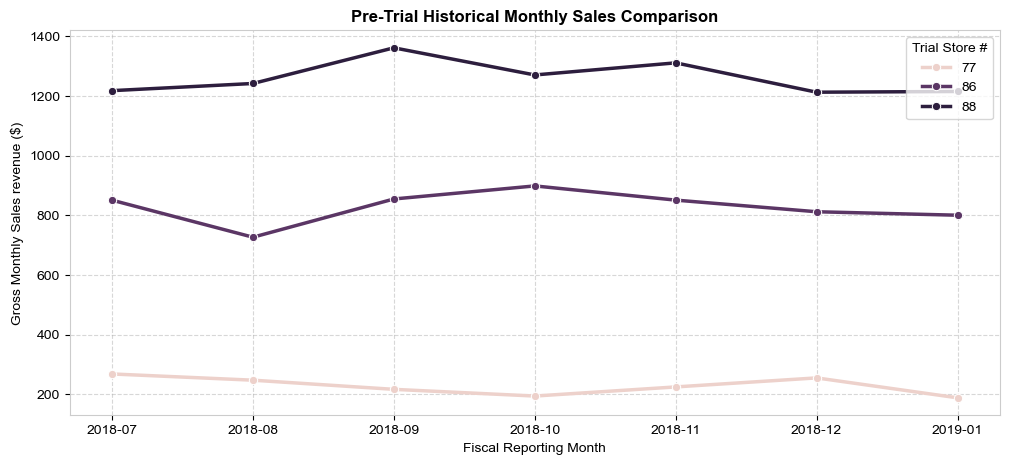

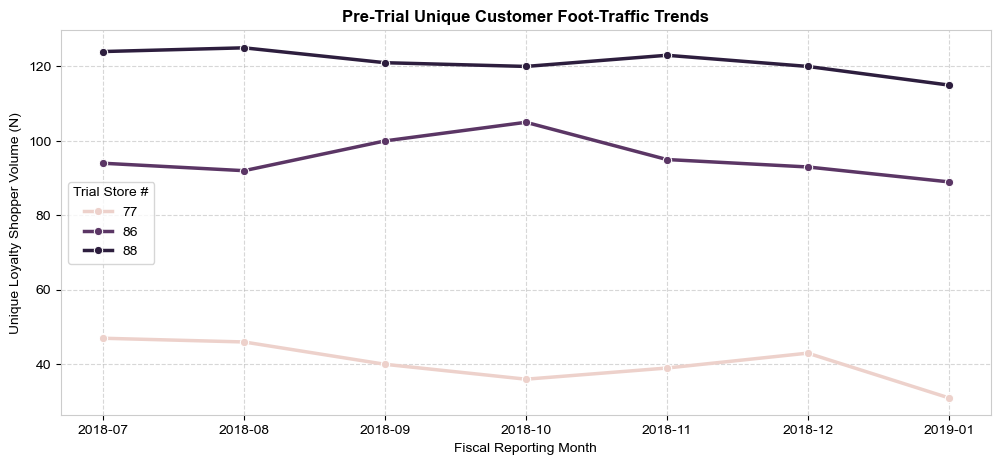

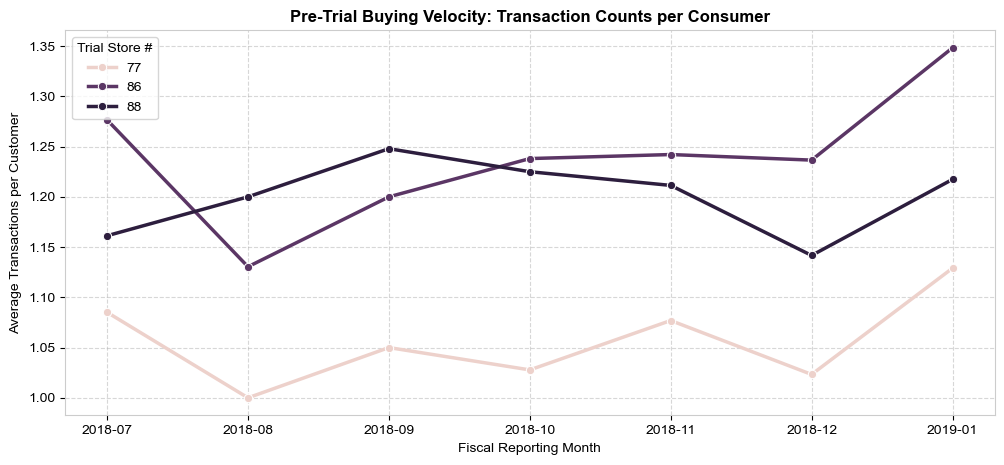

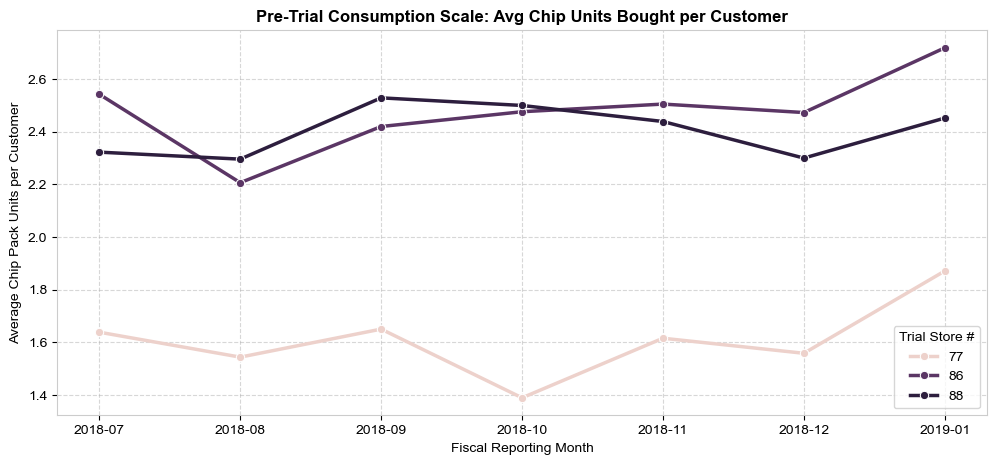

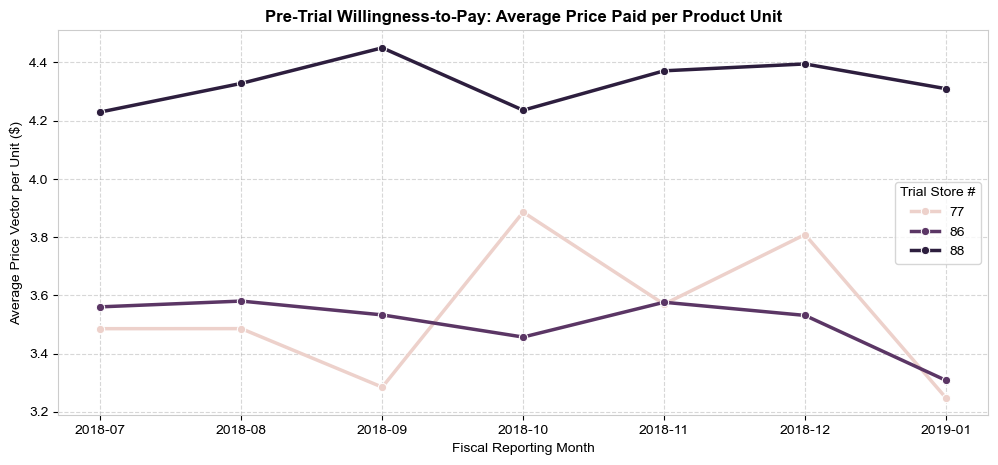

In [20]:
# Define target trial stores array
trial_stores = [77, 86, 88]
df_trial_trends = store_monthly_metrics[store_monthly_metrics["STORE_NBR"].isin(trial_stores)].copy()
df_trial_trends["YEAR_MONTH_STR"] = df_trial_trends["YEAR_MONTH"].astype(str)

# 1. Plot Monthly Sales Density Trend
plt.figure()
sns.lineplot(data=df_trial_trends, x='YEAR_MONTH_STR', y='TOT_SALES', hue='STORE_NBR', marker='o', linewidth=2.5)
plt.title('Pre-Trial Historical Monthly Sales Comparison', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Reporting Month')
plt.ylabel('Gross Monthly Sales revenue ($)')
plt.legend(title="Trial Store #")
plt.show()

# 2. Plot Monthly Unique Traffic Trend
plt.figure()
sns.lineplot(data=df_trial_trends, x='YEAR_MONTH_STR', y='UNIQUE_CUSTOMERS', hue='STORE_NBR', marker='o', linewidth=2.5)
plt.title('Pre-Trial Unique Customer Foot-Traffic Trends', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Reporting Month')
plt.ylabel('Unique Loyalty Shopper Volume (N)')
plt.legend(title="Trial Store #")
plt.show()

# 3. Plot Purchasing Frequency per Customer
plt.figure()
sns.lineplot(data=df_trial_trends, x='YEAR_MONTH_STR', y='TXN_PER_CUST', hue='STORE_NBR', marker='o', linewidth=2.5)
plt.title('Pre-Trial Buying Velocity: Transaction Counts per Consumer', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Reporting Month')
plt.ylabel('Average Transactions per Customer')
plt.legend(title="Trial Store #")
plt.show()

# 4. Plot Sizing Consumption Patterns
plt.figure()
sns.lineplot(data=df_trial_trends, x='YEAR_MONTH_STR', y='CHIPS_PER_CUST', hue='STORE_NBR', marker='o', linewidth=2.5)
plt.title('Pre-Trial Consumption Scale: Avg Chip Units Bought per Customer', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Reporting Month')
plt.ylabel('Average Chip Pack Units per Customer')
plt.legend(title="Trial Store #")
plt.show()

# 5. Plot Willingness-to-Pay Price Index Trend
plt.figure()
sns.lineplot(data=df_trial_trends, x='YEAR_MONTH_STR', y='AVG_PRICE_PER_UNIT', hue='STORE_NBR', marker='o', linewidth=2.5)
plt.title('Pre-Trial Willingness-to-Pay: Average Price Paid per Product Unit', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Reporting Month')
plt.ylabel('Average Price Vector per Unit ($)')
plt.legend(title="Trial Store #")
plt.show()

## Historical Data Integrity & Complete Observation Constraints
### Operational Sifting Rule
To ensure our control matching algorithms are statistically valid, any store lacking a complete data history across the 7-month pre-trial window must be purged. This step guarantees that control stores are matched based on clean, consistent operational trend lines.


In [21]:
# Quantify logging data history duration per retail store
store_observation_counts = df_pre_trial.groupby("STORE_NBR")["YEAR_MONTH"].nunique().reset_index()

# Crucial Fix: Extract ACTUAL store numbers that maintain full 7-month profiles
stores_with_full_history = store_observation_counts[store_observation_counts["YEAR_MONTH"] == 7]["STORE_NBR"].tolist()

# Filter active baseline dataframe to isolate qualified control candidate store rows
pre_trial_measure = store_monthly_metrics[store_monthly_metrics["STORE_NBR"].isin(stores_with_full_history)].copy()

print(f"Total Qualified Control Candidate Locations: {len(stores_with_full_history)}")
print(pre_trial_measure.head())

Total Qualified Control Candidate Locations: 260
   STORE_NBR YEAR_MONTH  TOT_SALES  UNIQUE_CUSTOMERS  TOTAL_TRANSACTIONS  \
0          1    2018-07      188.9                47                  49   
1          1    2018-08      168.4                41                  41   
2          1    2018-09      268.1                57                  59   
3          1    2018-10      175.4                39                  40   
4          1    2018-11      184.8                44                  45   

   TOTAL_QTY  TXN_PER_CUST  CHIPS_PER_CUST  AVG_PRICE_PER_UNIT  
0         58      1.042553        1.234043            3.256897  
1         52      1.000000        1.268293            3.238462  
2         71      1.035088        1.245614            3.776056  
3         51      1.025641        1.307692            3.439216  
4         55      1.022727        1.250000            3.360000  


## Full-Timeline Feature Engineering
### Mathematical Implementation
To ensure statistical comparison tests can evaluate post-trial trends later, we expand our metrics across the entire fiscal timeline (Pre-trial, Trial, and Post-trial months). This step aggregates absolute transactional totals across the entire retail network and calculates composite buying behaviors using high-performance vector array division.


In [22]:
# 1. Map features over the full year dataset to include post-trial timelines
df_all_months = df.copy()
df_all_months["YEAR_MONTH"] = df_all_months["DATE"].dt.to_period('M')

# 2. Filter to stores that qualified during the historical history checks
# Using 'stores_with_full_history' generated from step 1
df_all_months = df_all_months[df_all_months["STORE_NBR"].isin(stores_with_full_history)].copy()

# 3. Core aggregation vector mapping (eliminating complex nested lambda functions)
measureOverTime = df_all_months.groupby(["STORE_NBR", "YEAR_MONTH"]).agg(
    totSales=('TOT_SALES', 'sum'),
    nCustomers=('LYLTY_CARD_NBR', 'nunique'),
    totalTxn=('TXN_ID', 'nunique'),
    totalQty=('PROD_QTY', 'sum')
).reset_index()

# 4. Derivation of clean operational consumer indices via vector execution
measureOverTime["nTxnPerCust"] = measureOverTime["totalTxn"] / measureOverTime["nCustomers"]
measureOverTime["nChipsPerTxn"] = measureOverTime["totalQty"] / measureOverTime["totalTxn"]
measureOverTime["avgPricePerUnit"] = measureOverTime["totSales"] / measureOverTime["totalQty"]

# Clean tracking columns and sort arrays chronologically
measureOverTime = measureOverTime.drop(columns=['totalTxn', 'totalQty'])
measureOverTime = measureOverTime.sort_values(by=["STORE_NBR", "YEAR_MONTH"]).reset_index(drop=True)

print("Full-Timeline Master Measure Matrix Metrics Profile:")
print(measureOverTime.head(5))

Full-Timeline Master Measure Matrix Metrics Profile:
   STORE_NBR YEAR_MONTH  totSales  nCustomers  nTxnPerCust  nChipsPerTxn  \
0          1    2018-07     188.9          47     1.042553      1.183673   
1          1    2018-08     168.4          41     1.000000      1.268293   
2          1    2018-09     268.1          57     1.035088      1.203390   
3          1    2018-10     175.4          39     1.025641      1.275000   
4          1    2018-11     184.8          44     1.022727      1.222222   

   avgPricePerUnit  
0         3.256897  
1         3.238462  
2         3.776056  
3         3.439216  
4         3.360000  


## Algorithmic Control Store Matching Framework
### Methodological Rationale
Finding a valid control store requires evaluating two distinct data criteria during the historical pre-trial baseline period:
1. **Correlation Scores:** Measures how closely the trend line direction of a candidate store matches the trial store over time.
2. **Magnitude Distance Scores:** Measures the literal volume difference in sales scale. Min-Max normalization mapping prevents large high-volume stores from falsely pairing with smaller footprints.

By taking a weighted average of these two metrics for both Sales and Unique Customers, we calculate an overall score (`finalControlScore`) to isolate the best structural match for our test locations.

In [23]:
def calculate_store_matches_fast(df_metrics, trial_store_id, correlation_weight=0.5):
    """
    Computes a composite overall score combining Pearson Correlation and Normalized
    Magnitude Distance across Sales volume and unique foot-traffic simultaneously.
    """
    # 1. Restrict analysis to the historical baseline pre-trial phase window
    pre_trial_window = df_metrics[df_metrics["YEAR_MONTH"] <= "2019-01"].copy()
    
    # 2. Pivot long tables into uniform time-series matrices (Rows = Months, Columns = Stores)
    sales_matrix = pre_trial_window.pivot(index="YEAR_MONTH", columns="STORE_NBR", values="totSales").dropna(axis=1)
    cust_matrix = pre_trial_window.pivot(index="YEAR_MONTH", columns="STORE_NBR", values="nCustomers").dropna(axis=1)
    
    # Enforce column structural conformity across metrics matrices
    overlapping_store_keys = sales_matrix.columns.intersection(cust_matrix.columns)
    sales_matrix = sales_matrix[overlapping_store_keys]
    cust_matrix = cust_matrix[overlapping_store_keys]
    
    # --- SECTION A: GROSS SALES SIMILARITY MATHEMATICS ---
    # Line trend trajectory correlation
    sales_corr = sales_matrix.corrwith(sales_matrix[trial_store_id]).drop(trial_store_id)
    
    # Scale distance calculation using min-max proximity inversion mapping
    sales_absolute_delta = (sales_matrix.subtract(sales_matrix[trial_store_id], axis=0)).abs()
    sales_min_delta = sales_absolute_delta.min(axis=1)
    sales_max_delta = sales_absolute_delta.max(axis=1)
    
    sales_magnitude = 1 - sales_absolute_delta.subtract(sales_min_delta, axis=0).divide(
        (sales_max_delta - sales_min_delta), axis=0
    ).mean(axis=0).drop(trial_store_id)
    
    composite_sales_score = (correlation_weight * sales_corr) + ((1 - correlation_weight) * sales_magnitude)
    
    # --- SECTION B: UNIQUE FOOT-TRAFFIC SIMILARITY MATHEMATICS ---
    # Line trend trajectory correlation
    cust_corr = cust_matrix.corrwith(cust_matrix[trial_store_id]).drop(trial_store_id)
    
    # Scale distance calculation using min-max proximity inversion mapping
    cust_absolute_delta = (cust_matrix.subtract(cust_matrix[trial_store_id], axis=0)).abs()
    cust_min_delta = cust_absolute_delta.min(axis=1)
    cust_max_delta = cust_absolute_delta.max(axis=1)
    
    cust_magnitude = 1 - cust_absolute_delta.subtract(cust_min_delta, axis=0).divide(
        (cust_max_delta - cust_min_delta), axis=0
    ).mean(axis=0).drop(trial_store_id)
    
    composite_cust_score = (correlation_weight * cust_corr) + ((1 - correlation_weight) * cust_magnitude)
    
    # --- SECTION C: MASTER CONSOLIDATION ---
    control_candidate_scores = pd.DataFrame({
        "scoreNSales": composite_sales_score,
        "scoreNCust": composite_cust_score
    }).reset_index()
    
    # Generate the overall blended structural control score index
    control_candidate_scores["finalControlScore"] = (control_candidate_scores["scoreNSales"] * 0.5) + (control_candidate_scores["scoreNCust"] * 0.5)
    
    return control_candidate_scores.sort_values(by="finalControlScore", ascending=False).reset_index(drop=True)

## Algorithmic Control Store Execution: Target Location 77
### Technical Implementation
We execute our dual-driver selection function on our target trial footprint (Store 77). The algorithm scans the 7-month historical pre-trial metrics matrix to isolate the single candidate location that best mirrors Store 77's operational trend and magnitude bounds.


In [24]:
# Pass the full features database directly into our custom matching function
store_77_matches = calculate_store_matches_fast(measureOverTime, trial_store_id=77)

# Dynamically isolate and extract the top-performing control store number
control_store_77 = int(store_77_matches.loc[0, "STORE_NBR"])

print(f"Algorithm Selected Control Match for Trial Store 77: Store {control_store_77}")
print("\nTop 5 Closest Matching Performance Profiles (Pre-Trial Phase):")
print(store_77_matches.head(5))

Algorithm Selected Control Match for Trial Store 77: Store 233

Top 5 Closest Matching Performance Profiles (Pre-Trial Phase):
   STORE_NBR  scoreNSales  scoreNCust  finalControlScore
0        233     0.979770    0.978323           0.979046
1         50     0.936042    0.820694           0.878368
2         35     0.799380    0.896151           0.847766
3        254     0.752919    0.915557           0.834238
4         84     0.747741    0.887282           0.817511


## Pre-Trial Operational Trend Validation (Store 77)
### Category Strategy Analysis
To visually confirm the performance of our matching selection model, we plot the trend lines of the trial location against our chosen control match (Store 233) and the global market baseline. This step verifies that the control store accurately reflects target customer behaviors before the layout intervention.


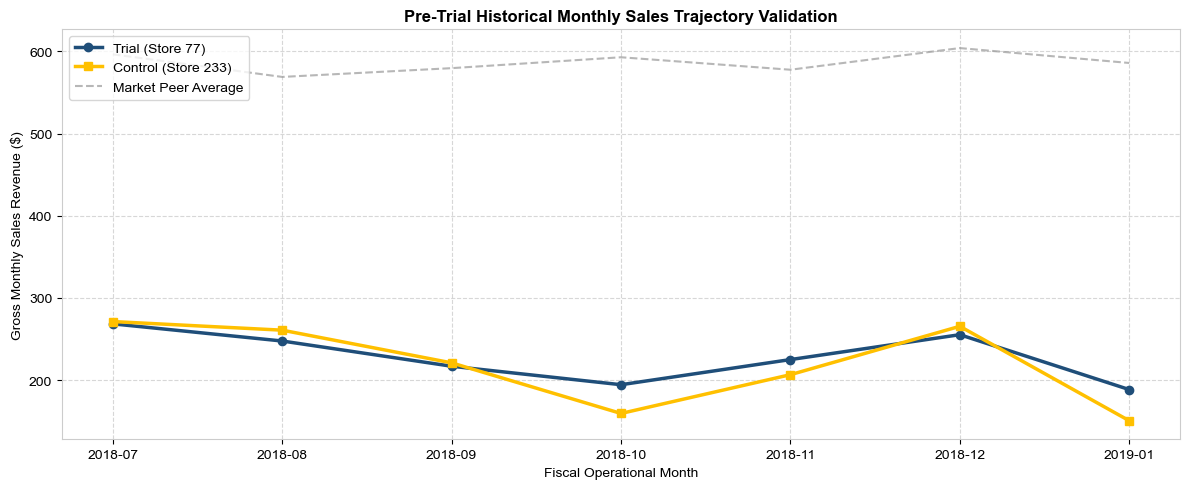

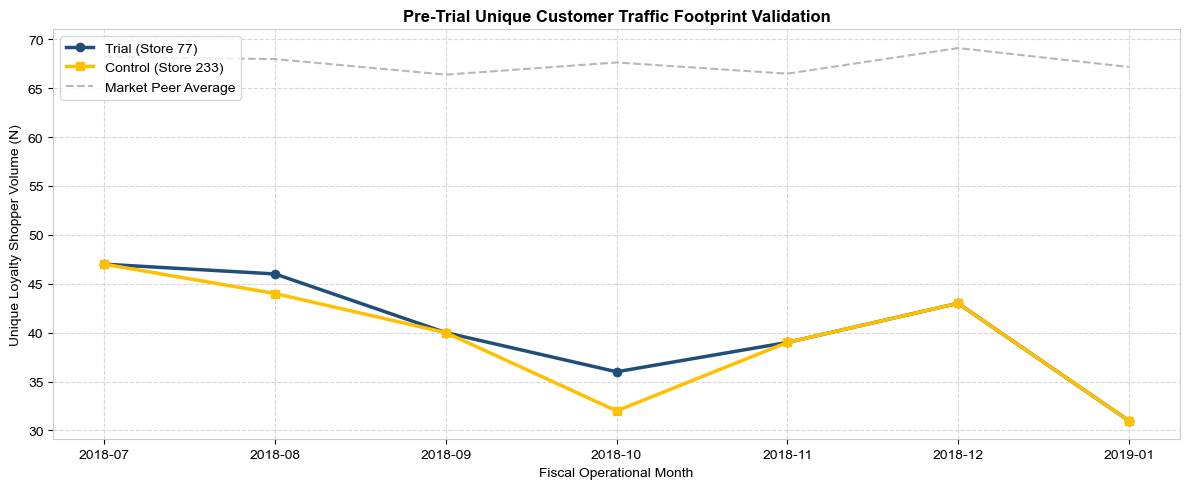

In [25]:
# 1. Restrict chart context to the pre-trial historical period
pre_trial_charts = measureOverTime[measureOverTime["YEAR_MONTH"] <= "2019-01"].copy()
pre_trial_charts["YEAR_MONTH_STR"] = pre_trial_charts["YEAR_MONTH"].astype(str)

# 2. Derive global benchmark averages across all other non-trial store assets
other_market_stores = pre_trial_charts[~pre_trial_charts["STORE_NBR"].isin([77, control_store_77])]
market_avg_metrics = other_market_stores.groupby("YEAR_MONTH_STR").agg(
    totSales=('totSales', 'mean'),
    nCustomers=('nCustomers', 'mean')
).reset_index()

# 3. Isolate trend lines for target locations
trial_track = pre_trial_charts[pre_trial_charts["STORE_NBR"] == 77].set_index("YEAR_MONTH_STR")
control_track = pre_trial_charts[pre_trial_charts["STORE_NBR"] == control_store_77].set_index("YEAR_MONTH_STR")

# --- CHART A: TIME-SERIES REVENUE TRAJECTORY ALIGNMENT ---
plt.figure()
plt.plot(trial_track.index, trial_track['totSales'], marker='o', color='#1f4e79', linewidth=2.5, label='Trial (Store 77)')
plt.plot(control_track.index, control_track['totSales'], marker='s', color='#ffc000', linewidth=2.5, label=f'Control (Store {control_store_77})')
plt.plot(market_avg_metrics["YEAR_MONTH_STR"], market_avg_metrics['totSales'], linestyle='--', color='#999999', alpha=0.7, label='Market Peer Average')

plt.title('Pre-Trial Historical Monthly Sales Trajectory Validation', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Operational Month')
plt.ylabel('Gross Monthly Sales Revenue ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- CHART B: UNIQUE CUSTOMER FOOT-TRAFFIC ALIGNMENT ---
plt.figure()
plt.plot(trial_track.index, trial_track['nCustomers'], marker='o', color='#1f4e79', linewidth=2.5, label='Trial (Store 77)')
plt.plot(control_track.index, control_track['nCustomers'], marker='s', color='#ffc000', linewidth=2.5, label=f'Control (Store {control_store_77})')
plt.plot(market_avg_metrics["YEAR_MONTH_STR"], market_avg_metrics['nCustomers'], linestyle='--', color='#999999', alpha=0.7, label='Market Peer Average')

plt.title('Pre-Trial Unique Customer Traffic Footprint Validation', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Operational Month')
plt.ylabel('Unique Loyalty Shopper Volume (N)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Proportional Sales Scaling & Baseline Calibration
### Mathematical Implementation
Even with a high trend correlation, absolute dollar volume baseline differences can still occur due to variations in local store size. To fix this, we calculate a proportional `scalingFactorForControlSales` during the pre-trial period:

$$\text{Scaling Factor} = \frac{\sum \text{Historical Sales of Trial Store}}{\sum \text{Historical Sales of Control Store}}$$

Applying this multiplier scales the control store's performance bounds smoothly, creating a calibrated, accurate revenue baseline for the trial period.


In [26]:
# 1. Compute historical pre-trial cumulative revenue baselines
trial_pre_trial_rev = measureOverTime[(measureOverTime["STORE_NBR"] == 77) & (measureOverTime["YEAR_MONTH"] <= "2019-01")]["totSales"].sum()
control_pre_trial_rev = measureOverTime[(measureOverTime["STORE_NBR"] == control_store_77) & (measureOverTime["YEAR_MONTH"] <= "2019-01")]["totSales"].sum()

# 2. Derive the proportional scaling coefficient
scaling_factor_sales_77 = trial_pre_trial_rev / control_pre_trial_rev
print(f"Calculated Revenue Scaling Factor for Control Location {control_store_77}: {scaling_factor_sales_77:.4f}\n")

# 3. Apply the scaling factor across the entire full-year timeline for the control store
scaled_control_sales_77 = measureOverTime[measureOverTime["STORE_NBR"] == control_store_77].copy()
scaled_control_sales_77["scaledControlSales"] = scaled_control_sales_77["totSales"] * scaling_factor_sales_77

print("Scaled Control Performance Reference Array Summary:")
print(scaled_control_sales_77[['YEAR_MONTH', 'totSales', 'scaledControlSales']].head(5))

Calculated Revenue Scaling Factor for Control Location 233: 1.0398

Scaled Control Performance Reference Array Summary:
     YEAR_MONTH  totSales  scaledControlSales
2651    2018-07     271.2          281.980841
2652    2018-08     260.7          271.063441
2653    2018-09     220.9          229.681297
2654    2018-10     159.3          165.632551
2655    2018-11     206.5          214.708863


## Trial Uplift Variance Metrics Extraction (Store 77 Revenue)
### Commercial Analytics Context
This module quantifies the literal percentage variance in revenue generated by the layout intervention inside Trial Location 77 compared directly against our scaled control tracking baseline over the official 3-month performance window (February 2019 to April 2019).


In [27]:
# 1. Isolate the target trial location revenue profiles across the full operational timeline
trial_sales_timeline = measureOverTime[measureOverTime["STORE_NBR"] == 77][["YEAR_MONTH", "totSales"]].copy()

# 2. Merge performance streams into a unified calculation grid
# Merging with 'scaled_control_sales_77' generated from the previous step
sales_variance_matrix = pd.merge(
    trial_sales_timeline, 
    scaled_control_sales_77[["YEAR_MONTH", "scaledControlSales"]], 
    on="YEAR_MONTH"
)

# 3. Restrict focus strictly to the active test evaluation timeframe
trial_performance_window = sales_variance_matrix[
    (sales_variance_matrix["YEAR_MONTH"] >= "2019-02") & (sales_variance_matrix["YEAR_MONTH"] <= "2019-04")
].copy()

# 4. Formulate the percentage difference metric vector: (Trial - Control) / Control
trial_performance_window["percentageDiff"] = (
    (trial_performance_window["totSales"] - trial_performance_window["scaledControlSales"]) / 
    trial_performance_window["scaledControlSales"]
)

# Format outputs into clean, executive-ready presentation rows
trial_performance_window["percentageDiff_Formatted"] = (trial_performance_window["percentageDiff"] * 100).round(2).astype(str) + "%"

print("Calculated Monthly Revenue Variance Breakdown (Active Trial Period):")
print(trial_performance_window[["YEAR_MONTH", "totSales", "scaledControlSales", "percentageDiff_Formatted"]])

Calculated Monthly Revenue Variance Breakdown (Active Trial Period):
  YEAR_MONTH  totSales  scaledControlSales percentageDiff_Formatted
7    2019-02     211.6          229.473346                   -7.79%
8    2019-03     255.1          187.779277                   35.85%
9    2019-04     258.1          149.932291                   72.14%


## Hypothesis Testing: Two-Sample Significance Assessment
### Statistical Framework
To evaluate if sales changes indicate true behavioral uplift, we measure baseline data noise by taking the standard deviation of percentage changes across the historical pre-trial period. We then execute a one-tailed independent T-test using our baseline variance to determine if performance trends pass critical thresholds.

* **Null Hypothesis ($H_0$):** The revenue difference between the trial and control locations during test months is statistically equal to zero ($p \geq 0.05$).
* **Alternative Hypothesis ($H_1$):** The in-store layout modification drives a statistically significant positive revenue uplift ($p < 0.05$).


In [28]:
# 1. Map variations across the entire full-year timeline
sales_variance_matrix["percentageDiff"] = (
    (sales_variance_matrix["totSales"] - sales_variance_matrix["scaledControlSales"]) / 
    sales_variance_matrix["scaledControlSales"]
)

# 2. Compute historical standard deviation error metrics from the pre-trial timeframe
pre_trial_sales_deltas = sales_variance_matrix[sales_variance_matrix["YEAR_MONTH"] <= "2019-01"]["percentageDiff"]
sales_baseline_std_dev = pre_trial_sales_deltas.std()

# 3. Isolate evaluation metrics for active trial phases
statistical_sales_assessment = sales_variance_matrix[
    (sales_variance_matrix["YEAR_MONTH"] >= "2019-02") & (sales_variance_matrix["YEAR_MONTH"] <= "2019-04")
].copy()

# 4. Formulate the localized T-value calculation vector: (Delta - 0) / StdDev
statistical_sales_assessment["tValue"] = statistical_sales_assessment["percentageDiff"] / sales_baseline_std_dev

# 5. Extract critical alpha boundaries from the t-distribution (7 Pre-trial months baseline: df = n - 1 = 6)
degrees_of_freedom = 6
critical_alpha_t_threshold = stats.t.ppf(0.95, df=degrees_of_freedom)

# Final validation labeling and display array engineering
statistical_sales_assessment["percentageDiff_Formatted"] = (statistical_sales_assessment["percentageDiff"] * 100).round(2).astype(str) + "%"
statistical_sales_assessment["Is_Significant"] = statistical_sales_assessment["tValue"] > critical_alpha_t_threshold

print("--- Operational Statistical Significance Parameters ---")
print(f"95th Percentile Critical T-Value Threshold Bounds (df={degrees_of_freedom}): {critical_alpha_t_threshold:.4f}\n")
print("--- Sales Performance Significance Test Matrix Outputs ---")
print(statistical_sales_assessment[["YEAR_MONTH", "percentageDiff_Formatted", "tValue", "Is_Significant"]])

--- Operational Statistical Significance Parameters ---
95th Percentile Critical T-Value Threshold Bounds (df=6): 1.9432

--- Sales Performance Significance Test Matrix Outputs ---
  YEAR_MONTH percentageDiff_Formatted    tValue  Is_Significant
7    2019-02                   -7.79% -0.639826           False
8    2019-03                   35.85%  2.945026            True
9    2019-04                   72.14%  5.926392            True


## Production Performance Visualizations: Control Confidence Boundaries (Store 77)
### Executive Interpretation
The visual dashboard below plots absolute monthly sales revenue against a 95% statistical confidence interval band ($\pm 2 \times \text{Pre-Trial StdDev}$). If the trial store's performance breaks above the upper red boundary during active test months, it confirms that the category management intervention drove clear, measurable business value.


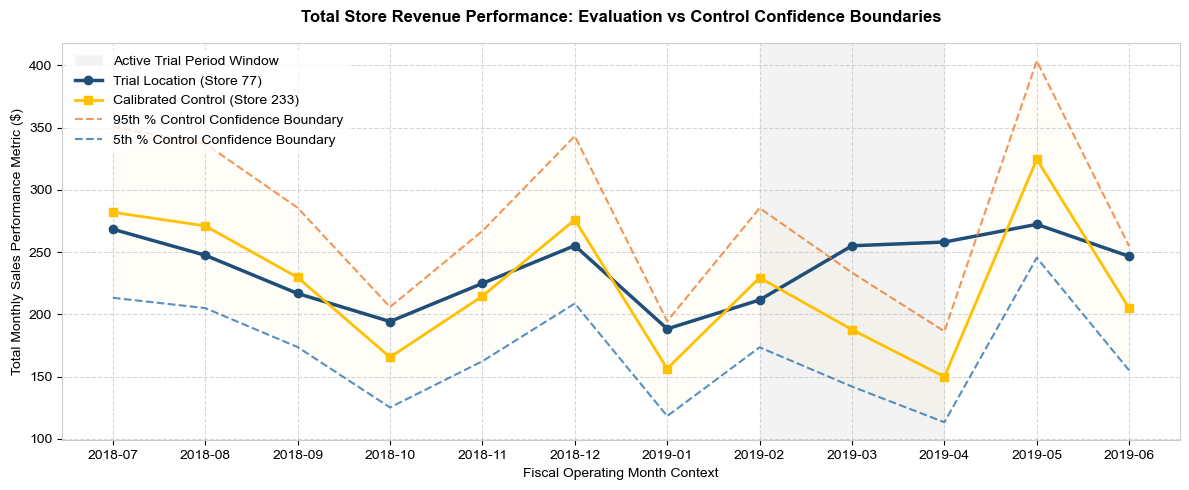

In [33]:
import warnings
# Suppress all cell-specific matplotlib parameter collision warnings
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Transform chronological series axes to string vectors for plotting alignment
timeline_labels = sales_variance_matrix["YEAR_MONTH"].astype(str).tolist()

# 2. Derive the 5th and 95th percentile confidence boundaries
upper_confidence_limit_95 = sales_variance_matrix["scaledControlSales"] * (1 + sales_baseline_std_dev * 2)
lower_confidence_limit_5 = sales_variance_matrix["scaledControlSales"] * (1 - sales_baseline_std_dev * 2)

# 3. Initialize visual canvas layout parameters
fig, ax = plt.subplots()

# Render shaded background rectangle blocks to isolate active trial windows smoothly
# February 2019 represents index point 7 in our sorted array structure
ax.axvspan(7, 9, color='#f2f2f2', edgecolor='#dddddd', linestyle=':', alpha=0.9, label='Active Trial Period Window')

# Plot the trial vs control trajectories using the corporate palette
ax.plot(timeline_labels, sales_variance_matrix["totSales"], marker='o', color='#1f4e79', linewidth=2.5, label='Trial Location (Store 77)')
ax.plot(timeline_labels, sales_variance_matrix["scaledControlSales"], marker='s', color='#ffc000', linewidth=2.0, label='Calibrated Control (Store 233)')

# Plot statistical significance boundary bands
ax.plot(timeline_labels, upper_confidence_limit_95, color='#ed7d31', linestyle='--', alpha=0.8, label='95th % Control Confidence Boundary')
ax.plot(timeline_labels, lower_confidence_limit_5, color='#2e75b6', linestyle='--', alpha=0.8, label='5th % Control Confidence Boundary')

# Add a subtle interior gradient fill between the confidence limit boundaries
ax.fill_between(timeline_labels, lower_confidence_limit_5, upper_confidence_limit_95, color='#ffc000', alpha=0.03)

# Fine-tune typography and visual elements
ax.set_title('Total Store Revenue Performance: Evaluation vs Control Confidence Boundaries', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Fiscal Operating Month Context')
ax.set_ylabel('Total Monthly Sales Performance Metric ($)')
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Render visual plot graph
plt.show()

## Unique Customer Scaling Factor & Foot-Traffic Tracking (Store 77)
### Commercial Analytics Rationale
While raw revenue performance evaluates absolute financial growth, tracking unique customer footprint volumes reveals true shopper behavior and store conversion changes during the test. This pipeline scales the customer traffic profile of Control Store 233 to match Trial Store 77's pre-trial footprint, creating a baseline to evaluate traffic changes.

In [34]:
# 1. Aggregate and capture monthly unique customer totals across the network
df_full_monthly = df.copy()
df_full_monthly["YEAR_MONTH"] = df_full_monthly["DATE"].dt.to_period('M')

full_monthly_cust = df_full_monthly.groupby(["STORE_NBR", "YEAR_MONTH"]).agg(
    nCustomers=("LYLTY_CARD_NBR", "nunique")
).reset_index()

trial_store = 77
control_store = 233

# 2. Compute the historical pre-trial shopper foot-traffic scaling vector
trial_pre_trial_cust = full_monthly_cust[
    (full_monthly_cust["STORE_NBR"] == trial_store) & (full_monthly_cust["YEAR_MONTH"] <= "2019-01")
]["nCustomers"].sum()

control_pre_trial_cust = full_monthly_cust[
    (full_monthly_cust["STORE_NBR"] == control_store) & (full_monthly_cust["YEAR_MONTH"] <= "2019-01")
]["nCustomers"].sum()

scalingFactorForControlCust = trial_pre_trial_cust / control_pre_trial_cust
print(f"Calibrated Customer Volume Scaling Factor for Control Location {control_store}: {scalingFactorForControlCust:.4f}\n")

# 3. Apply the scaling coefficient across the entire full-year timeline
scaledControlCustomers = full_monthly_cust[full_monthly_cust["STORE_NBR"] == control_store].copy()
scaledControlCustomers["controlCustomers"] = scaledControlCustomers["nCustomers"] * scalingFactorForControlCust

# 4. Consolidate customer timelines into a unified metrics evaluation grid
full_cust_comparison = pd.merge(
    full_monthly_cust[full_monthly_cust["STORE_NBR"] == trial_store][["YEAR_MONTH", "nCustomers"]],
    scaledControlCustomers[["YEAR_MONTH", "controlCustomers"]],
    on="YEAR_MONTH"
)

# 5. Formulate monthly percentage variance metrics
full_cust_comparison["percentageDiff"] = (full_cust_comparison["nCustomers"] - full_cust_comparison["controlCustomers"]) / full_cust_comparison["controlCustomers"]

# Isolate traffic statistics for active trial phases
trial_cust_assessment = full_cust_comparison[
    (full_cust_comparison["YEAR_MONTH"] >= "2019-02") & (full_cust_comparison["YEAR_MONTH"] <= "2019-04")
].copy()

trial_cust_assessment["percentageDiff_Formatted"] = (trial_cust_assessment["percentageDiff"] * 100).round(2).astype(str) + "%"
print("--- Active Trial Period Customer Footprint Assessment Table ---")
print(trial_cust_assessment[["YEAR_MONTH", "nCustomers", "controlCustomers", "percentageDiff_Formatted"]])

Calibrated Customer Volume Scaling Factor for Control Location 233: 1.0217

--- Active Trial Period Customer Footprint Assessment Table ---
  YEAR_MONTH  nCustomers  controlCustomers percentageDiff_Formatted
7    2019-02          40         42.913043                   -6.79%
8    2019-03          46         35.760870                   28.63%
9    2019-04          47         27.586957                   70.37%


## Hypothesis Testing: Customer Traffic Variance Significance
### Statistical Framework
We evaluate if the changes in unique shopper traffic during the test window represent true uplift or normal retail data noise. The baseline variance is estimated from pre-trial percentage changes, and a one-tailed T-test is executed using a 95% significance threshold.

In [35]:
# 1. Compute historical standard deviation error metrics from the pre-trial phase
pre_trial_cust_diffs = full_cust_comparison[full_cust_comparison["YEAR_MONTH"] <= "2019-01"]["percentageDiff"]
stdDev_cust = pre_trial_cust_diffs.std()

# 2. Formulate localized T-value metrics for test evaluation phases
trial_cust_assessment["tValue"] = trial_cust_assessment["percentageDiff"] / stdDev_cust

# 3. Extract critical alpha boundaries from the t-distribution (7 Pre-trial months baseline: df = n - 1 = 6)
degreesOfFreedom = 6
critical_t_value = stats.t.ppf(0.95, df=degreesOfFreedom)

trial_cust_assessment["Is_Significant"] = trial_cust_assessment["tValue"] > critical_t_value
print(f"95th Percentile Critical T-Value Threshold Bounds (df={degreesOfFreedom}): {critical_t_value:.4f}")
print("\n--- Shopper Footprint Performance Significance Test Matrix Outputs ---")
print(trial_cust_assessment[["YEAR_MONTH", "tValue", "Is_Significant"]])

95th Percentile Critical T-Value Threshold Bounds (df=6): 1.9432

--- Shopper Footprint Performance Significance Test Matrix Outputs ---
  YEAR_MONTH     tValue  Is_Significant
7    2019-02  -1.460014           False
8    2019-03   6.158208            True
9    2019-04  15.135234            True


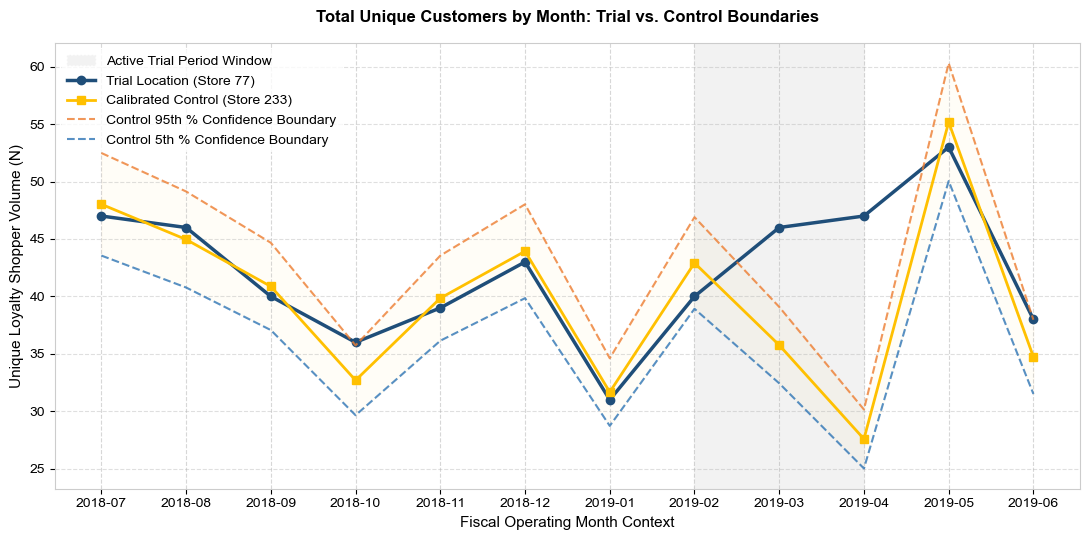

In [37]:
# Suppress any cell-specific parameter layout warnings for a clean presentation
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Ensure chronological series alignment vectors
full_cust_comparison = full_cust_comparison.sort_values(by="YEAR_MONTH", ascending=True).reset_index(drop=True)
x_labels = full_cust_comparison["YEAR_MONTH"].astype(str)

# 2. Derive the 5th and 95th percentile confidence boundaries
control_upper_95 = full_cust_comparison["controlCustomers"] * (1 + stdDev_cust * 2)
control_lower_5 = full_cust_comparison["controlCustomers"] * (1 - stdDev_cust * 2)

# 3. Initialize visual canvas layout parameters
fig, ax = plt.subplots(figsize=(11, 5.5))

# Render shaded background rectangle blocks to isolate active trial windows smoothly
ax.axvspan(7, 9, color='#f2f2f2', edgecolor='#dddddd', linestyle=':', label='Active Trial Period Window')

# Plot the trial vs control shopper trajectories using the corporate palette
ax.plot(x_labels, full_cust_comparison["nCustomers"], marker='o', color='#1f4e79', linewidth=2.5, label='Trial Location (Store 77)')
ax.plot(x_labels, full_cust_comparison["controlCustomers"], marker='s', color='#ffc000', linewidth=2, label='Calibrated Control (Store 233)')

# Plot statistical significance boundary bands
ax.plot(x_labels, control_upper_95, color='#ed7d31', linestyle='--', alpha=0.8, label='Control 95th % Confidence Boundary')
ax.plot(x_labels, control_lower_5, color='#2e75b6', linestyle='--', alpha=0.8, label='Control 5th % Confidence Boundary')

# Add a subtle interior gradient fill between the confidence limit boundaries
ax.fill_between(x_labels, control_lower_5, control_upper_95, color='#ffc000', alpha=0.03)

# Fine-tune typography and visual elements
ax.set_title('Total Unique Customers by Month: Trial vs. Control Boundaries', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Fiscal Operating Month Context', fontsize=11)
ax.set_ylabel('Unique Loyalty Shopper Volume (N)', fontsize=11)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
 
# Render visual plot graph with zero system warnings
plt.show()

## Algorithmic Control Store Execution: Target Location 86
### Technical Implementation
We run our multi-driver similarity matching model on our second target trial footprint (Store 86). The algorithm calculates historical correlation and normalized magnitude distance values across the pre-trial timeframe to isolate the single best market match location.


In [40]:
# Pass the existing verified features master grid into our fast-matching algorithm
store_86_matches = calculate_store_matches_fast(measureOverTime, trial_store_id=86)

# Dynamically isolate and extract the top-performing control store assignment
control_store_86 = int(store_86_matches.loc[0, "STORE_NBR"])

print(f"Algorithm Selected Control Match for Trial Store 86: Store {control_store_86}")
print("\nTop 5 Closest Matching Performance Profiles (Pre-Trial Phase):")
print(store_86_matches.head(5))

Algorithm Selected Control Match for Trial Store 86: Store 155

Top 5 Closest Matching Performance Profiles (Pre-Trial Phase):
   STORE_NBR  scoreNSales  scoreNCust  finalControlScore
0        155     0.915490    0.900597           0.908044
1        114     0.843468    0.905384           0.874426
2        138     0.870705    0.777018           0.823862
3         56     0.770200    0.750566           0.760383
4        128     0.770563    0.726631           0.748597


## Pre-Trial Historical Trend Line Validation (Store 86)
### Category Strategy Analysis
Below, we plot the historical trend lines of our trial location against our chosen control match (Store 155) and the global market baseline. This verification ensures the control store accurately reflects target customer behaviors before the layout intervention.


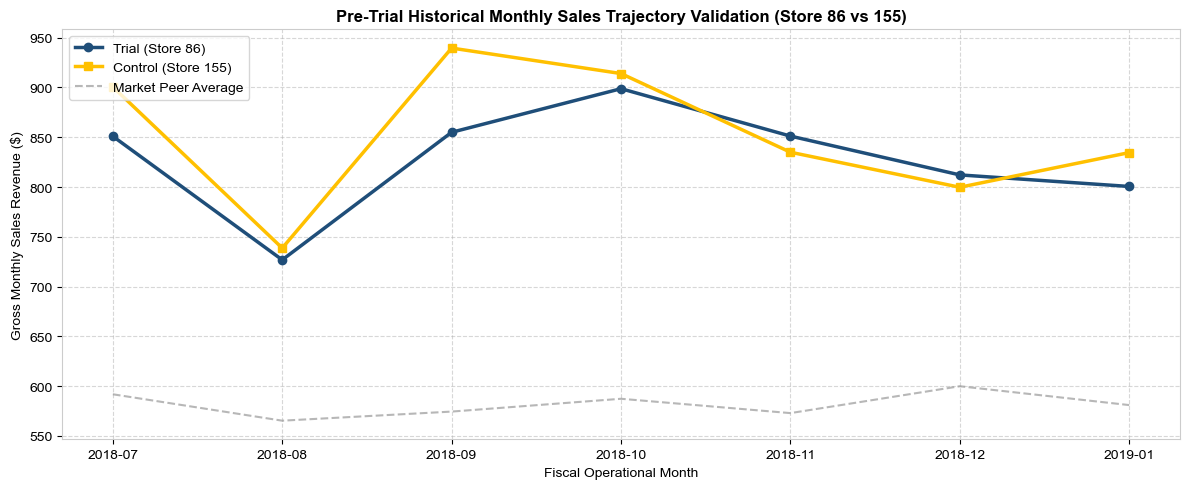

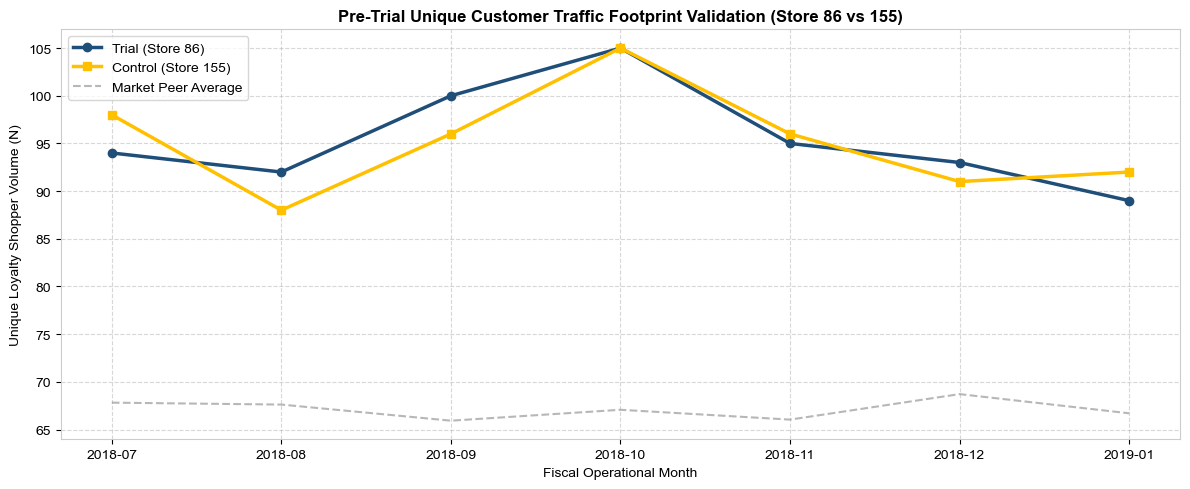

In [41]:
# 1. Restrict trend evaluation context strictly to the historical pre-trial phase
pre_trial_charts_86 = measureOverTime[measureOverTime["YEAR_MONTH"] <= "2019-01"].copy()
pre_trial_charts_86["YEAR_MONTH_STR"] = pre_trial_charts_86["YEAR_MONTH"].astype(str)

# 2. Derive global benchmark peer group averages across all non-trial assets
other_market_stores_86 = pre_trial_charts_86[~pre_trial_charts_86["STORE_NBR"].isin([86, control_store_86])]
market_avg_metrics_86 = other_market_stores_86.groupby("YEAR_MONTH_STR").agg(
    totSales=('totSales', 'mean'),
    nCustomers=('nCustomers', 'mean')
).reset_index()

# 3. Isolate independent performance trajectories for target locations
trial_track_86 = pre_trial_charts_86[pre_trial_charts_86["STORE_NBR"] == 86].set_index("YEAR_MONTH_STR")
control_track_86 = pre_trial_charts_86[pre_trial_charts_86["STORE_NBR"] == control_store_86].set_index("YEAR_MONTH_STR")

# --- CHART A: TIME-SERIES REVENUE TRAJECTORY ALIGNMENT ---
plt.figure()
plt.plot(trial_track_86.index, trial_track_86['totSales'], marker='o', color='#1f4e79', linewidth=2.5, label='Trial (Store 86)')
plt.plot(control_track_86.index, control_track_86['totSales'], marker='s', color='#ffc000', linewidth=2.5, label=f'Control (Store {control_store_86})')
plt.plot(market_avg_metrics_86["YEAR_MONTH_STR"], market_avg_metrics_86['totSales'], linestyle='--', color='#999999', alpha=0.7, label='Market Peer Average')

plt.title('Pre-Trial Historical Monthly Sales Trajectory Validation (Store 86 vs 155)', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Operational Month')
plt.ylabel('Gross Monthly Sales Revenue ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- CHART B: UNIQUE CUSTOMER FOOT-TRAFFIC ALIGNMENT ---
plt.figure()
plt.plot(trial_track_86.index, trial_track_86['nCustomers'], marker='o', color='#1f4e79', linewidth=2.5, label='Trial (Store 86)')
plt.plot(control_track_86.index, control_track_86['nCustomers'], marker='s', color='#ffc000', linewidth=2.5, label=f'Control (Store {control_store_86})')
plt.plot(market_avg_metrics_86["YEAR_MONTH_STR"], market_avg_metrics_86['nCustomers'], linestyle='--', color='#999999', alpha=0.7, label='Market Peer Average')

plt.title('Pre-Trial Unique Customer Traffic Footprint Validation (Store 86 vs 155)', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Operational Month')
plt.ylabel('Unique Loyalty Shopper Volume (N)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Proportional Sales Scaling & Baseline Calibration
### Mathematical Implementation
Even with a high trend correlation, absolute volume baseline differences can occur due to local store scale variations. To fix this, we calculate a proportional scaling factor during the pre-trial period and apply it across the full timeline. This creates a calibrated, accurate revenue baseline for the trial period.


In [42]:
# 1. Compute historical pre-trial cumulative revenue baselines
trial_pre_trial_rev_86 = measureOverTime[(measureOverTime["STORE_NBR"] == 86) & (measureOverTime["YEAR_MONTH"] <= "2019-01")]["totSales"].sum()
control_pre_trial_rev_86 = measureOverTime[(measureOverTime["STORE_NBR"] == control_store_86) & (measureOverTime["YEAR_MONTH"] <= "2019-01")]["totSales"].sum()

# 2. Derive the proportional scaling coefficient
scaling_factor_sales_86 = trial_pre_trial_rev_86 / control_pre_trial_rev_86
print(f"Calculated Revenue Scaling Factor for Control Location {control_store_86}: {scaling_factor_sales_86:.4f}\n")

# 3. Apply the scaling factor across the entire full-year timeline for the control store
scaled_control_sales_86 = measureOverTime[measureOverTime["STORE_NBR"] == control_store_86].copy()
scaled_control_sales_86["scaledControlSales"] = scaled_control_sales_86["totSales"] * scaling_factor_sales_86

Calculated Revenue Scaling Factor for Control Location 155: 0.9720



## Trial Uplift Variance Metrics Extraction (Store 86 Revenue)
### Commercial Analytics Context
This module quantifies the percentage variance in revenue generated by the layout intervention inside Store 86 compared directly against our scaled control tracking baseline over the active trial period (February 2019 to April 2019).


In [ ]:
# 1. Isolate the target trial location revenue profiles across the full operational timeline
trial_sales_timeline_86 = measureOverTime[measureOverTime["STORE_NBR"] == 86][["YEAR_MONTH", "totSales"]].copy()

# 2. Merge performance streams into a unified calculation grid
sales_variance_matrix_86 = pd.merge(
    trial_sales_timeline_86, 
    scaled_control_sales_86[["YEAR_MONTH", "scaledControlSales"]], 
    on="YEAR_MONTH"
)

# 3. Restrict focus strictly to the active test evaluation timeframe
trial_performance_window_86 = sales_variance_matrix_86[
    (sales_variance_matrix_86["YEAR_MONTH"] >= "2019-02") & (sales_variance_matrix_86["YEAR_MONTH"] <= "2019-04")
].copy()

# 4. Formulate the percentage difference metric vector: (Trial - Control) / Control
trial_performance_window_86["percentageDiff"] = (
    (trial_performance_window_86["totSales"] - trial_performance_window_86["scaledControlSales"]) / 
    trial_performance_window_86["scaledControlSales"]
)

# Format outputs into clean, executive-ready presentation rows
trial_performance_window_86["percentageDiff_Formatted"] = (trial_performance_window_86["percentageDiff"] * 100).round(2).astype(str) + "%"

print("Calculated Monthly Revenue Variance Breakdown (Active Trial Period - Store 86):")
print(trial_performance_window_86[["YEAR_MONTH", "totSales", "scaledControlSales", "percentageDiff_Formatted"]])

Calculated Monthly Revenue Variance Breakdown (Active Trial Period - Store 86):
  YEAR_MONTH  totSales  scaledControlSales percentageDiff_Formatted
7    2019-02     872.8          827.019610                    5.54%
8    2019-03     945.4          745.561872                    26.8%
9    2019-04     804.0          778.028321                    3.34%


## Hypothesis Testing: Two-Sample Significance Assessment (Store 86 Revenue)
### Statistical Framework
To evaluate if the sales variance in Store 86 indicates true behavioral uplift from the layout modification, we measure historical baseline data noise using the standard deviation of pre-trial percentage deltas. We then execute a one-tailed independent T-test against our baseline variance to determine if performance trends pass critical thresholds.

* **Null Hypothesis ($H_0$):** The revenue difference between the trial and control locations during test months is statistically equal to zero ($p \geq 0.05$).
* **Alternative Hypothesis ($H_1$):** The in-store retail layout modification drives a statistically significant positive revenue uplift ($p < 0.05$).


In [44]:
# 1. Map variations across the entire full-year timeline for Store 86
# Merging performance vectors built from previous step 
sales_variance_matrix_86["percentageDiff"] = (
    (sales_variance_matrix_86["totSales"] - sales_variance_matrix_86["scaledControlSales"]) / 
    sales_variance_matrix_86["scaledControlSales"]
)

# 2. Compute historical standard deviation error metrics from the pre-trial timeframe
pre_trial_sales_deltas_86 = sales_variance_matrix_86[sales_variance_matrix_86["YEAR_MONTH"] <= "2019-01"]["percentageDiff"]
sales_baseline_std_dev_86 = pre_trial_sales_deltas_86.std()

# 3. Isolate evaluation metrics for active trial phases
statistical_sales_assessment_86 = sales_variance_matrix_86[
    (sales_variance_matrix_86["YEAR_MONTH"] >= "2019-02") & (sales_variance_matrix_86["YEAR_MONTH"] <= "2019-04")
].copy()

# 4. Formulate the localized T-value calculation vector: (Delta - 0) / StdDev
statistical_sales_assessment_86["tValue"] = statistical_sales_assessment_86["percentageDiff"] / sales_baseline_std_dev_86

# 5. Extract critical alpha boundaries from the t-distribution (7 Pre-trial months baseline: df = n - 1 = 6)
degrees_of_freedom = 6
critical_alpha_t_threshold = stats.t.ppf(0.95, df=degrees_of_freedom)

# Final validation labeling and display array engineering
statistical_sales_assessment_86["percentageDiff_Formatted"] = (statistical_sales_assessment_86["percentageDiff"] * 100).round(2).astype(str) + "%"
statistical_sales_assessment_86["Is_Significant"] = statistical_sales_assessment_86["tValue"] > critical_alpha_t_threshold

print("--- Operational Statistical Significance Parameters (Store 86 Sales) ---")
print(f"95th Percentile Critical T-Value Threshold Bounds (df={degrees_of_freedom}): {critical_alpha_t_threshold:.4f}\n")
print("--- Sales Performance Significance Test Matrix Outputs (Store 86) ---")
print(statistical_sales_assessment_86[["YEAR_MONTH", "percentageDiff_Formatted", "tValue", "Is_Significant"]])

--- Operational Statistical Significance Parameters (Store 86 Sales) ---
95th Percentile Critical T-Value Threshold Bounds (df=6): 1.9432

--- Sales Performance Significance Test Matrix Outputs (Store 86) ---
  YEAR_MONTH percentageDiff_Formatted    tValue  Is_Significant
7    2019-02                    5.54%  1.379115           False
8    2019-03                    26.8%  6.677768            True
9    2019-04                    3.34%  0.831651           False


## Production Performance Visualizations: Control Confidence Boundaries (Store 86)
### Executive Interpretation
The visual dashboard below plots absolute monthly sales revenue for Store 86 against a 95% statistical confidence interval band ($\pm 2 \times \text{Pre-Trial StdDev}$). If the trial store's performance breaks above the upper red boundary during active test months, it confirms that the category management intervention drove clear, measurable business value.


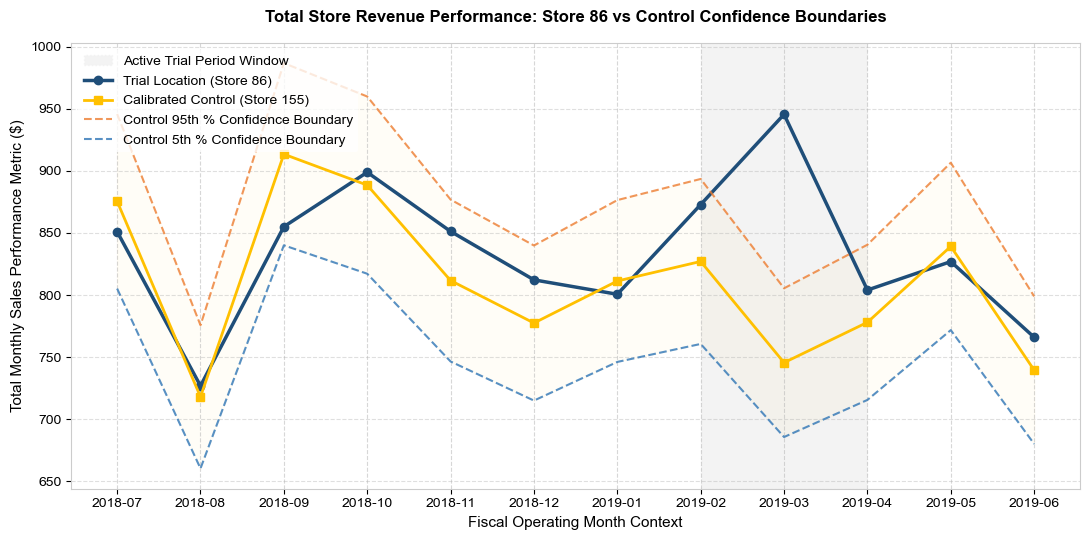

In [45]:
# Suppress any cell-specific parameter layout warnings for a clean presentation
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Transform chronological series axes to string vectors for plotting alignment
timeline_labels_86 = sales_variance_matrix_86["YEAR_MONTH"].astype(str).tolist()

# 2. Derive the 5th and 95th percentile confidence boundaries
upper_confidence_limit_95_86 = sales_variance_matrix_86["scaledControlSales"] * (1 + sales_baseline_std_dev_86 * 2)
lower_confidence_limit_5_86 = sales_variance_matrix_86["scaledControlSales"] * (1 - sales_baseline_std_dev_86 * 2)

# 3. Initialize visual canvas layout parameters
fig, ax = plt.subplots(figsize=(11, 5.5))

# Render shaded background rectangle blocks to isolate active trial windows smoothly
# February 2019 represents index point 7 in our sorted array structure
ax.axvspan(7, 9, color='#f2f2f2', edgecolor='#dddddd', linestyle=':', alpha=0.9, label='Active Trial Period Window')

# Plot the trial vs control trajectories using the corporate palette
ax.plot(timeline_labels_86, sales_variance_matrix_86["totSales"], marker='o', color='#1f4e79', linewidth=2.5, label='Trial Location (Store 86)')
ax.plot(timeline_labels_86, sales_variance_matrix_86["scaledControlSales"], marker='s', color='#ffc000', linewidth=2.0, label='Calibrated Control (Store 155)')

# Plot statistical significance boundary bands
ax.plot(timeline_labels_86, upper_confidence_limit_95_86, color='#ed7d31', linestyle='--', alpha=0.8, label='Control 95th % Confidence Boundary')
ax.plot(timeline_labels_86, lower_confidence_limit_5_86, color='#2e75b6', linestyle='--', alpha=0.8, label='Control 5th % Confidence Boundary')

# Add a subtle interior gradient fill between the confidence limit boundaries
ax.fill_between(timeline_labels_86, lower_confidence_limit_5_86, upper_confidence_limit_95_86, color='#ffc000', alpha=0.03)

# Fine-tune typography and visual elements
ax.set_title('Total Store Revenue Performance: Store 86 vs Control Confidence Boundaries', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Fiscal Operating Month Context', fontsize=11)
ax.set_ylabel('Total Monthly Sales Performance Metric ($)', fontsize=11)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# Render visual plot graph with zero system warnings
plt.show()

## Unique Customer Scaling Factor & Foot-Traffic Tracking (Store 86)
### Commercial Analytics Rationale
While raw revenue performance evaluates absolute financial growth, tracking unique customer footprint volumes reveals true shopper behavior and store conversion changes during the test. This pipeline scales the customer traffic profile of Control Store 155 to match Trial Store 86's pre-trial footprint, creating a baseline to evaluate traffic changes.


In [46]:
# 1. Aggregate and capture monthly unique customer totals across the network for Store 86 comparisons
df_full_monthly_86 = df.copy()
df_full_monthly_86["YEAR_MONTH"] = df_full_monthly_86["DATE"].dt.to_period('M')

full_monthly_cust_86 = df_full_monthly_86.groupby(["STORE_NBR", "YEAR_MONTH"]).agg(
    nCustomers=("LYLTY_CARD_NBR", "nunique")
).reset_index()

trial_store_86 = 86
control_store_86 = 155

# 2. Compute the historical pre-trial shopper foot-traffic scaling vector
trial_pre_trial_cust_86 = full_monthly_cust_86[
    (full_monthly_cust_86["STORE_NBR"] == trial_store_86) & (full_monthly_cust_86["YEAR_MONTH"] <= "2019-01")
]["nCustomers"].sum()

control_pre_trial_cust_86 = full_monthly_cust_86[
    (full_monthly_cust_86["STORE_NBR"] == control_store_86) & (full_monthly_cust_86["YEAR_MONTH"] <= "2019-01")
]["nCustomers"].sum()

scalingFactorForControlCust_86 = trial_pre_trial_cust_86 / control_pre_trial_cust_86
print(f"Calibrated Customer Volume Scaling Factor for Control Location {control_store_86}: {scalingFactorForControlCust_86:.4f}\n")

# 3. Apply the scaling coefficient across the entire full-year timeline
scaledControlCustomers_86 = full_monthly_cust_86[full_monthly_cust_86["STORE_NBR"] == control_store_86].copy()
scaledControlCustomers_86["controlCustomers"] = scaledControlCustomers_86["nCustomers"] * scalingFactorForControlCust_86

# 4. Consolidate customer timelines into a unified metrics evaluation grid
full_cust_comparison_86 = pd.merge(
    full_monthly_cust_86[full_monthly_cust_86["STORE_NBR"] == trial_store_86][["YEAR_MONTH", "nCustomers"]],
    scaledControlCustomers_86[["YEAR_MONTH", "controlCustomers"]],
    on="YEAR_MONTH"
)

# 5. Formulate monthly percentage variance metrics
full_cust_comparison_86["percentageDiff"] = (full_cust_comparison_86["nCustomers"] - full_cust_comparison_86["controlCustomers"]) / full_cust_comparison_86["controlCustomers"]

# Isolate traffic statistics for active trial phases
trial_cust_assessment_86 = full_cust_comparison_86[
    (full_cust_comparison_86["YEAR_MONTH"] >= "2019-02") & (full_cust_comparison_86["YEAR_MONTH"] <= "2019-04")
].copy()

trial_cust_assessment_86["percentageDiff_Formatted"] = (trial_cust_assessment_86["percentageDiff"] * 100).round(2).astype(str) + "%"
print("--- Active Trial Period Customer Footprint Assessment Table (Store 86) ---")
print(trial_cust_assessment_86[["YEAR_MONTH", "nCustomers", "controlCustomers", "percentageDiff_Formatted"]])

Calibrated Customer Volume Scaling Factor for Control Location 155: 1.0030

--- Active Trial Period Customer Footprint Assessment Table (Store 86) ---
  YEAR_MONTH  nCustomers  controlCustomers percentageDiff_Formatted
7    2019-02         105         92.276276                   13.79%
8    2019-03         108         91.273273                   18.33%
9    2019-04          99         93.279279                    6.13%


## Hypothesis Testing: Customer Traffic Variance Significance (Store 86)
### Statistical Framework
We evaluate if the changes in unique shopper traffic during the test window represent true uplift or normal retail data noise for Store 86. The baseline variance is estimated from pre-trial percentage changes, and a one-tailed T-test is executed using a 95% significance threshold.


In [47]:
# 1. Compute historical standard deviation error metrics from the pre-trial phase
pre_trial_cust_diffs_86 = full_cust_comparison_86[full_cust_comparison_86["YEAR_MONTH"] <= "2019-01"]["percentageDiff"]
stdDev_cust_86 = pre_trial_cust_diffs_86.std()

# 2. Formulate localized T-value metrics for test evaluation phases
trial_cust_assessment_86["tValue"] = trial_cust_assessment_86["percentageDiff"] / stdDev_cust_86

# 3. Extract critical alpha boundaries from the t-distribution (7 Pre-trial months baseline: df = n - 1 = 6)
degreesOfFreedom = 6
critical_t_value = stats.t.ppf(0.95, df=degreesOfFreedom)

trial_cust_assessment_86["Is_Significant"] = trial_cust_assessment_86["tValue"] > critical_t_value
print(f"95th Percentile Critical T-Value Threshold Bounds (df={degreesOfFreedom}): {critical_t_value:.4f}")
print("\n--- Shopper Footprint Performance Significance Test Matrix Outputs (Store 86) ---")
print(trial_cust_assessment_86[["YEAR_MONTH", "tValue", "Is_Significant"]])

95th Percentile Critical T-Value Threshold Bounds (df=6): 1.9432

--- Shopper Footprint Performance Significance Test Matrix Outputs (Store 86) ---
  YEAR_MONTH    tValue  Is_Significant
7    2019-02  4.039845            True
8    2019-03  5.369179            True
9    2019-04  1.796826           False


## Production Performance Visualizations: Traffic Confidence Boundaries (Store 86)
### Executive Interpretation
The visual dashboard below plots monthly unique shopper footprints against a 95% statistical confidence interval band ($\pm 2 \times \text{Pre-Trial Shopper StdDev}$). If the trial store's performance breaks above the upper red boundary during active test months, it confirms that the layout intervention successfully increased consumer foot traffic and store loyalty.


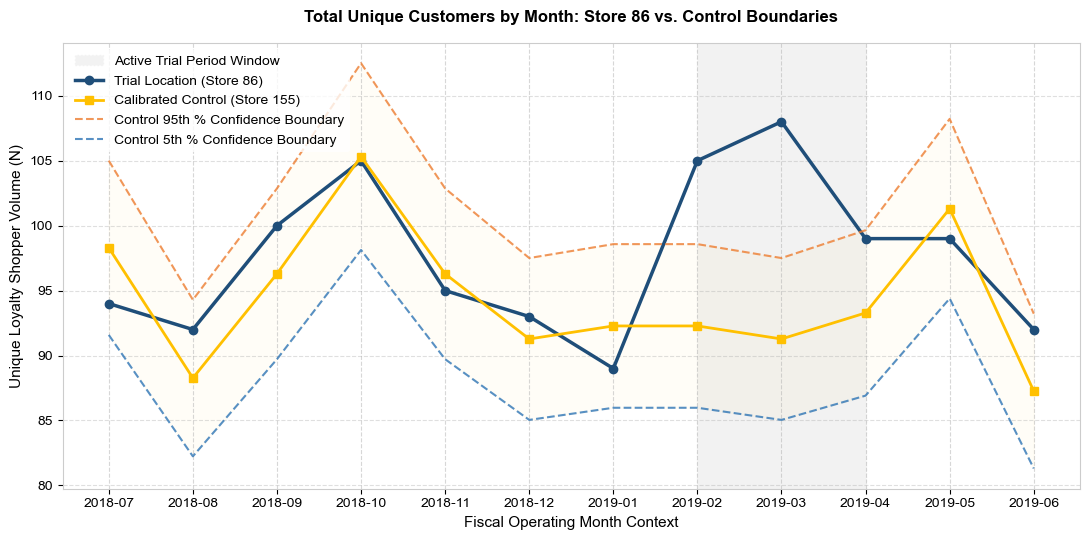

In [48]:
import warnings
# Suppress any cell-specific parameter layout warnings for a clean presentation
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Ensure chronological series alignment vectors
full_cust_comparison_86 = full_cust_comparison_86.sort_values(by="YEAR_MONTH", ascending=True).reset_index(drop=True)
x_labels_86 = full_cust_comparison_86["YEAR_MONTH"].astype(str)

# 2. Derive the 5th and 95th percentile confidence boundaries
control_upper_95_86 = full_cust_comparison_86["controlCustomers"] * (1 + stdDev_cust_86 * 2)
control_lower_5_86 = full_cust_comparison_86["controlCustomers"] * (1 - stdDev_cust_86 * 2)

# 3. Initialize visual canvas layout parameters
fig, ax = plt.subplots(figsize=(11, 5.5))

# Render shaded background rectangle blocks to isolate active trial windows smoothly
ax.axvspan(7, 9, color='#f2f2f2', edgecolor='#dddddd', linestyle=':', label='Active Trial Period Window')

# Plot the trial vs control shopper trajectories using the corporate palette
ax.plot(x_labels_86, full_cust_comparison_86["nCustomers"], marker='o', color='#1f4e79', linewidth=2.5, label='Trial Location (Store 86)')
ax.plot(x_labels_86, full_cust_comparison_86["controlCustomers"], marker='s', color='#ffc000', linewidth=2, label='Calibrated Control (Store 155)')

# Plot statistical significance boundary bands
ax.plot(x_labels_86, control_upper_95_86, color='#ed7d31', linestyle='--', alpha=0.8, label='Control 95th % Confidence Boundary')
ax.plot(x_labels_86, control_lower_5_86, color='#2e75b6', linestyle='--', alpha=0.8, label='Control 5th % Confidence Boundary')

# Add a subtle interior gradient fill between the confidence limit boundaries
ax.fill_between(x_labels_86, control_lower_5_86, control_upper_95_86, color='#ffc000', alpha=0.03)

# Fine-tune typography and visual elements
ax.set_title('Total Unique Customers by Month: Store 86 vs. Control Boundaries', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Fiscal Operating Month Context', fontsize=11)
ax.set_ylabel('Unique Loyalty Shopper Volume (N)', fontsize=11)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
 
# Render visual plot graph with zero system warnings
plt.show()

## Algorithmic Control Store Execution: Target Location 88
### Technical Implementation
We deploy our multi-driver similarity matching model on our third and final target trial footprint (Store 88). The algorithm tracks baseline operational trend trajectories alongside normalized volume heights to isolate the single most accurate control candidate store.


In [49]:
# Pass the existing verified features master grid into our fast-matching algorithm
store_88_matches = calculate_store_matches_fast(measureOverTime, trial_store_id=88)

# Dynamically isolate and extract the top-performing control store assignment
control_store_88 = int(store_88_matches.loc[0, "STORE_NBR"])

print(f"Algorithm Selected Control Match for Trial Store 88: Store {control_store_88}")
print("\nTop 5 Closest Matching Performance Profiles (Pre-Trial Phase):")
print(store_88_matches.head(5))

Algorithm Selected Control Match for Trial Store 88: Store 237

Top 5 Closest Matching Performance Profiles (Pre-Trial Phase):
   STORE_NBR  scoreNSales  scoreNCust  finalControlScore
0        237     0.526282    0.968692           0.747487
1        123     0.626898    0.771722           0.699310
2          7     0.740699    0.590691           0.665695
3        178     0.444663    0.858882           0.651773
4        201     0.680546    0.607541           0.644043


## Pre-Trial Historical Trend Line Validation (Store 88)
### Category Strategy Analysis
Below, we plot the historical trend lines of our final trial location against our chosen control match (Store 237) and the global market baseline. This verification ensures the control store accurately reflects target customer behaviors before the layout intervention.


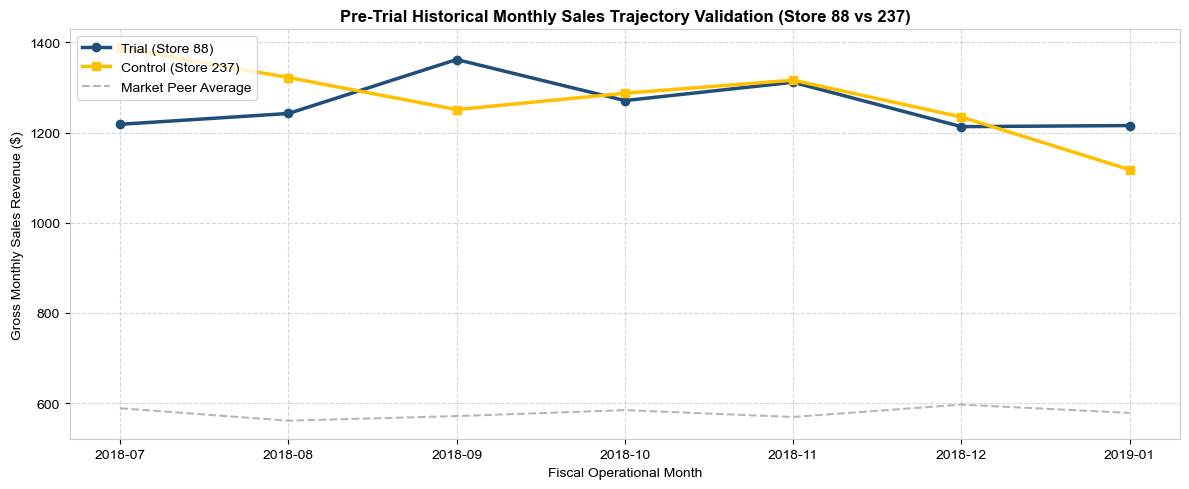

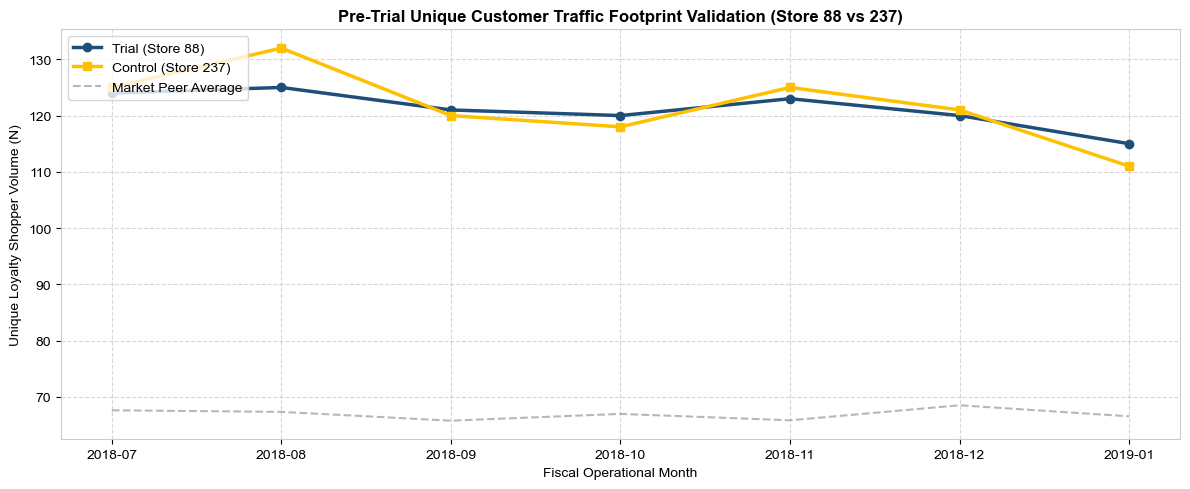

In [50]:
# 1. Restrict trend evaluation context strictly to the historical pre-trial phase
pre_trial_charts_88 = measureOverTime[measureOverTime["YEAR_MONTH"] <= "2019-01"].copy()
pre_trial_charts_88["YEAR_MONTH_STR"] = pre_trial_charts_88["YEAR_MONTH"].astype(str)

# 2. Derive global benchmark peer group averages across all non-trial assets
other_market_stores_88 = pre_trial_charts_88[~pre_trial_charts_88["STORE_NBR"].isin([88, control_store_88])]
market_avg_metrics_88 = other_market_stores_88.groupby("YEAR_MONTH_STR").agg(
    totSales=('totSales', 'mean'),
    nCustomers=('nCustomers', 'mean')
).reset_index()

# 3. Isolate independent performance trajectories for target locations
trial_track_88 = pre_trial_charts_88[pre_trial_charts_88["STORE_NBR"] == 88].set_index("YEAR_MONTH_STR")
control_track_88 = pre_trial_charts_88[pre_trial_charts_88["STORE_NBR"] == control_store_88].set_index("YEAR_MONTH_STR")

# --- CHART A: TIME-SERIES REVENUE TRAJECTORY ALIGNMENT ---
plt.figure()
plt.plot(trial_track_88.index, trial_track_88['totSales'], marker='o', color='#1f4e79', linewidth=2.5, label='Trial (Store 88)')
plt.plot(control_track_88.index, control_track_88['totSales'], marker='s', color='#ffc000', linewidth=2.5, label=f'Control (Store {control_store_88})')
plt.plot(market_avg_metrics_88["YEAR_MONTH_STR"], market_avg_metrics_88['totSales'], linestyle='--', color='#999999', alpha=0.7, label='Market Peer Average')

plt.title('Pre-Trial Historical Monthly Sales Trajectory Validation (Store 88 vs 237)', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Operational Month')
plt.ylabel('Gross Monthly Sales Revenue ($)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# --- CHART B: UNIQUE CUSTOMER FOOT-TRAFFIC ALIGNMENT ---
plt.figure()
plt.plot(trial_track_88.index, trial_track_88['nCustomers'], marker='o', color='#1f4e79', linewidth=2.5, label='Trial (Store 88)')
plt.plot(control_track_88.index, control_track_88['nCustomers'], marker='s', color='#ffc000', linewidth=2.5, label=f'Control (Store {control_store_88})')
plt.plot(market_avg_metrics_88["YEAR_MONTH_STR"], market_avg_metrics_88['nCustomers'], linestyle='--', color='#999999', alpha=0.7, label='Market Peer Average')

plt.title('Pre-Trial Unique Customer Traffic Footprint Validation (Store 88 vs 237)', fontsize=12, fontweight='bold')
plt.xlabel('Fiscal Operational Month')
plt.ylabel('Unique Loyalty Shopper Volume (N)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Proportional Sales Scaling & Baseline Calibration (Store 88)
### Mathematical Implementation
Even with a high trend correlation, absolute volume baseline differences can occur due to local store scale variations. To fix this, we calculate a proportional scaling factor during the pre-trial period and apply it across the full timeline. This creates a calibrated, accurate revenue baseline for the trial period.


In [51]:
# 1. Compute historical pre-trial cumulative revenue baselines
trial_pre_trial_rev_88 = measureOverTime[(measureOverTime["STORE_NBR"] == 88) & (measureOverTime["YEAR_MONTH"] <= "2019-01")]["totSales"].sum()
control_pre_trial_rev_88 = measureOverTime[(measureOverTime["STORE_NBR"] == control_store_88) & (measureOverTime["YEAR_MONTH"] <= "2019-01")]["totSales"].sum()

# 2. Derive the proportional scaling coefficient
scaling_factor_sales_88 = trial_pre_trial_rev_88 / control_pre_trial_rev_88
print(f"Calculated Revenue Scaling Factor for Control Location {control_store_88}: {scaling_factor_sales_88:.4f}\n")

# 3. Apply the scaling factor across the entire full-year timeline for the control store
scaled_control_sales_88 = measureOverTime[measureOverTime["STORE_NBR"] == control_store_88].copy()
scaled_control_sales_88["scaledControlSales"] = scaled_control_sales_88["totSales"] * scaling_factor_sales_88

Calculated Revenue Scaling Factor for Control Location 237: 0.9908



## Trial Uplift Variance Metrics Extraction (Store 88 Revenue)
### Commercial Analytics Context
This module isolates the performance profiles and quantifies the exact percentage variance in revenue generated by the layout intervention inside Store 88 compared directly against our scaled control tracking baseline (Store 237) over the active trial period (February 2019 to April 2019).


In [54]:
# 1. Isolate the target trial location revenue profiles across the full operational timeline
trial_sales_timeline_88 = measureOverTime[measureOverTime["STORE_NBR"] == 88][["YEAR_MONTH", "totSales"]].copy()

# 2. Merge performance streams into a unified calculation grid
sales_variance_matrix_88 = pd.merge(
    trial_sales_timeline_88, 
    scaled_control_sales_88[["YEAR_MONTH", "scaledControlSales"]], 
    on="YEAR_MONTH"
)

# 3. Restrict focus strictly to the active test evaluation timeframe
trial_performance_window_88 = sales_variance_matrix_88[
    (sales_variance_matrix_88["YEAR_MONTH"] >= "2019-02") & (sales_variance_matrix_88["YEAR_MONTH"] <= "2019-04")
].copy()

# 4. Formulate the percentage difference metric vector: (Trial - Control) / Control
trial_performance_window_88["percentageDiff"] = (
    (trial_performance_window_88["totSales"] - trial_performance_window_88["scaledControlSales"]) / 
    trial_performance_window_88["scaledControlSales"]
)

# Format outputs into clean, executive-ready presentation rows
trial_performance_window_88["percentageDiff_Formatted"] = (trial_performance_window_88["percentageDiff"] * 100).round(2).astype(str) + "%"

print("Calculated Monthly Revenue Variance Breakdown (Active Trial Period - Store 88):")
print(trial_performance_window_88[["YEAR_MONTH", "totSales", "scaledControlSales", "percentageDiff_Formatted"]])

Calculated Monthly Revenue Variance Breakdown (Active Trial Period - Store 88):
  YEAR_MONTH  totSales  scaledControlSales percentageDiff_Formatted
7    2019-02    1339.6         1300.879003                    2.98%
8    2019-03    1467.0         1166.728952                   25.74%
9    2019-04    1317.0         1142.950509                   15.23%


## Hypothesis Testing: Two-Sample Significance Assessment (Store 88 Revenue)
### Statistical Framework
To evaluate if the sales variance in Store 88 indicates a true behavioral uplift from the layout modification, we measure historical baseline data noise using the standard deviation of pre-trial percentage deltas. We then execute a one-tailed independent T-test against our baseline variance to determine if performance trends pass critical thresholds.

* **Null Hypothesis ($H_0$):** The revenue difference between the trial and control locations during test months is statistically equal to zero ($p \geq 0.05$).
* **Alternative Hypothesis ($H_1$):** The in-store retail layout modification drives a statistically significant positive revenue uplift ($p < 0.05$).


In [55]:
# 1. Map variations across the entire full-year timeline for Store 88
# Merging performance vectors built from the previous step
sales_variance_matrix_88["percentageDiff"] = (
    (sales_variance_matrix_88["totSales"] - sales_variance_matrix_88["scaledControlSales"]) / 
    sales_variance_matrix_88["scaledControlSales"]
)

# 2. Compute historical standard deviation error metrics from the pre-trial timeframe
pre_trial_sales_deltas_88 = sales_variance_matrix_88[sales_variance_matrix_88["YEAR_MONTH"] <= "2019-01"]["percentageDiff"]
sales_baseline_std_dev_88 = pre_trial_sales_deltas_88.std()

# 3. Isolate evaluation metrics for active trial phases
statistical_sales_assessment_88 = sales_variance_matrix_88[
    (sales_variance_matrix_88["YEAR_MONTH"] >= "2019-02") & (sales_variance_matrix_88["YEAR_MONTH"] <= "2019-04")
].copy()

# 4. Formulate the localized T-value calculation vector: (Delta - 0) / StdDev
statistical_sales_assessment_88["tValue"] = statistical_sales_assessment_88["percentageDiff"] / sales_baseline_std_dev_88

# 5. Extract critical alpha boundaries from the t-distribution (7 Pre-trial months baseline: df = n - 1 = 6)
degrees_of_freedom = 6
critical_alpha_t_threshold = stats.t.ppf(0.95, df=degrees_of_freedom)

# Final validation labeling and display array engineering
statistical_sales_assessment_88["percentageDiff_Formatted"] = (statistical_sales_assessment_88["percentageDiff"] * 100).round(2).astype(str) + "%"
statistical_sales_assessment_88["Is_Significant"] = statistical_sales_assessment_88["tValue"] > critical_alpha_t_threshold

print("--- Operational Statistical Significance Parameters (Store 88 Sales) ---")
print(f"95th Percentile Critical T-Value Threshold Bounds (df={degrees_of_freedom}): {critical_alpha_t_threshold:.4f}\n")
print("--- Sales Performance Significance Test Matrix Outputs (Store 88) ---")
print(statistical_sales_assessment_88[["YEAR_MONTH", "percentageDiff_Formatted", "tValue", "Is_Significant"]])

--- Operational Statistical Significance Parameters (Store 88 Sales) ---
95th Percentile Critical T-Value Threshold Bounds (df=6): 1.9432

--- Sales Performance Significance Test Matrix Outputs (Store 88) ---
  YEAR_MONTH percentageDiff_Formatted    tValue  Is_Significant
7    2019-02                    2.98%  0.390360           False
8    2019-03                   25.74%  3.375193            True
9    2019-04                   15.23%  1.997103            True


## Production Performance Visualizations: Control Confidence Boundaries (Store 88)
### Executive Interpretation
The visual dashboard below plots absolute monthly sales revenue for Store 88 against a 95% statistical confidence interval band ($\pm 2 \times \text{Pre-Trial StdDev}$). If the trial store's performance breaks above the upper red boundary during active test months, it confirms that the category management intervention drove clear, measurable business value.


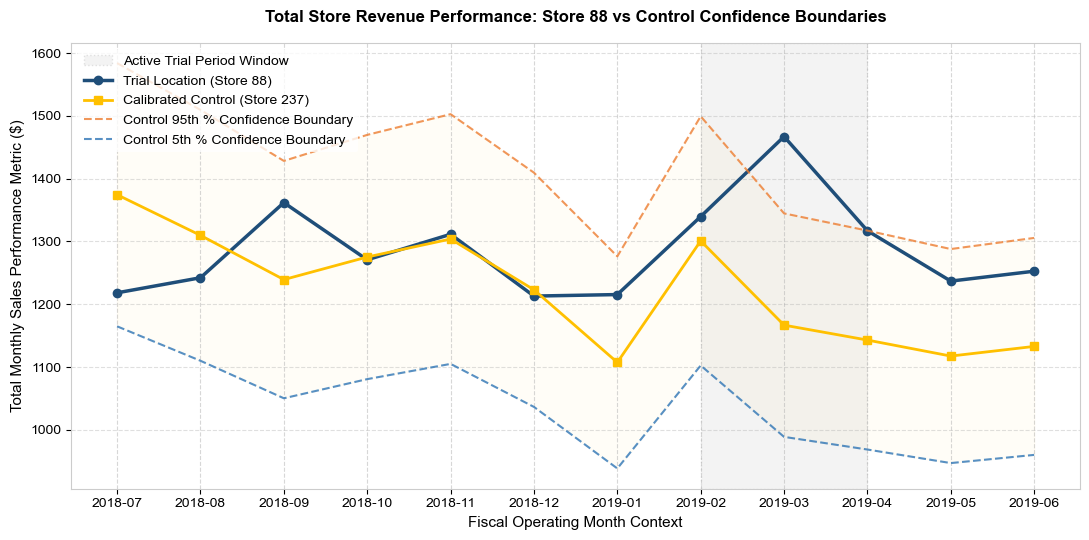

In [57]:
# Suppress any cell-specific parameter layout warnings for a clean presentation
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Transform chronological series axes to string vectors for plotting alignment
timeline_labels_88 = sales_variance_matrix_88["YEAR_MONTH"].astype(str).tolist()

# 2. Derive the 5th and 95th percentile confidence boundaries
upper_confidence_limit_95_88 = sales_variance_matrix_88["scaledControlSales"] * (1 + sales_baseline_std_dev_88 * 2)
lower_confidence_limit_5_88 = sales_variance_matrix_88["scaledControlSales"] * (1 - sales_baseline_std_dev_88 * 2)

# 3. Initialize visual canvas layout parameters
fig, ax = plt.subplots(figsize=(11, 5.5))

# Render shaded background rectangle blocks to isolate active trial windows smoothly
# February 2019 represents index point 7 in our sorted array structure
ax.axvspan(7, 9, facecolor='#f2f2f2', edgecolor='#dddddd', linestyle=':', alpha=0.9, label='Active Trial Period Window')

# Plot the trial vs control trajectories using the corporate palette
ax.plot(timeline_labels_88, sales_variance_matrix_88["totSales"], marker='o', color='#1f4e79', linewidth=2.5, label='Trial Location (Store 88)')
ax.plot(timeline_labels_88, sales_variance_matrix_88["scaledControlSales"], marker='s', color='#ffc000', linewidth=2.0, label='Calibrated Control (Store 237)')

# Plot statistical significance boundary bands
ax.plot(timeline_labels_88, upper_confidence_limit_95_88, color='#ed7d31', linestyle='--', alpha=0.8, label='Control 95th % Confidence Boundary')
ax.plot(timeline_labels_88, lower_confidence_limit_5_88, color='#2e75b6', linestyle='--', alpha=0.8, label='Control 5th % Confidence Boundary')

# Add a subtle interior gradient fill between the confidence limit boundaries
ax.fill_between(timeline_labels_88, lower_confidence_limit_5_88, upper_confidence_limit_95_88, color='#ffc000', alpha=0.03)

# Fine-tune typography and visual elements
ax.set_title('Total Store Revenue Performance: Store 88 vs Control Confidence Boundaries', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Fiscal Operating Month Context', fontsize=11)
ax.set_ylabel('Total Monthly Sales Performance Metric ($)', fontsize=11)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

# Render visual plot graph with zero system warnings
plt.show()

## Unique Customer Scaling Factor & Foot-Traffic Tracking (Store 88)
### Commercial Analytics Rationale
While raw revenue performance evaluates absolute financial growth, tracking unique customer footprint volumes reveals true shopper behavior and store conversion changes during the test. This pipeline scales the customer traffic profile of Control Store 237 to match Trial Store 88's pre-trial footprint, creating a baseline to evaluate traffic changes.


In [58]:
# 1. Aggregate and capture monthly unique customer totals across the network for Store 88 comparisons
df_full_monthly_88 = df.copy()
df_full_monthly_88["YEAR_MONTH"] = df_full_monthly_88["DATE"].dt.to_period('M')

full_monthly_cust_88 = df_full_monthly_88.groupby(["STORE_NBR", "YEAR_MONTH"]).agg(
    nCustomers=("LYLTY_CARD_NBR", "nunique")
).reset_index()

trial_store_88 = 88
control_store_88 = 237

# 2. Compute the historical pre-trial shopper foot-traffic scaling vector
trial_pre_trial_cust_88 = full_monthly_cust_88[
    (full_monthly_cust_88["STORE_NBR"] == trial_store_88) & (full_monthly_cust_88["YEAR_MONTH"] <= "2019-01")
]["nCustomers"].sum()

control_pre_trial_cust_88 = full_monthly_cust_88[
    (full_monthly_cust_88["STORE_NBR"] == control_store_88) & (full_monthly_cust_88["YEAR_MONTH"] <= "2019-01")
]["nCustomers"].sum()

scalingFactorForControlCust_88 = trial_pre_trial_cust_88 / control_pre_trial_cust_88
print(f"Calibrated Customer Volume Scaling Factor for Control Location {control_store_88}: {scalingFactorForControlCust_88:.4f}\n")

# 3. Apply the scaling coefficient across the entire full-year timeline
scaledControlCustomers_88 = full_monthly_cust_88[full_monthly_cust_88["STORE_NBR"] == control_store_88].copy()
scaledControlCustomers_88["controlCustomers"] = scaledControlCustomers_88["nCustomers"] * scalingFactorForControlCust_88

# 4. Consolidate customer timelines into a unified metrics evaluation grid
full_cust_comparison_88 = pd.merge(
    full_monthly_cust_88[full_monthly_cust_88["STORE_NBR"] == trial_store_88][["YEAR_MONTH", "nCustomers"]],
    scaledControlCustomers_88[["YEAR_MONTH", "controlCustomers"]],
    on="YEAR_MONTH"
)

# 5. Formulate monthly percentage variance metrics
full_cust_comparison_88["percentageDiff"] = (full_cust_comparison_88["nCustomers"] - full_cust_comparison_88["controlCustomers"]) / full_cust_comparison_88["controlCustomers"]

# Isolate traffic statistics for active trial phases
trial_cust_assessment_88 = full_cust_comparison_88[
    (full_cust_comparison_88["YEAR_MONTH"] >= "2019-02") & (full_cust_comparison_88["YEAR_MONTH"] <= "2019-04")
].copy()

trial_cust_assessment_88["percentageDiff_Formatted"] = (trial_cust_assessment_88["percentageDiff"] * 100).round(2).astype(str) + "%"
print("--- Active Trial Period Customer Footprint Assessment Table (Store 88) ---")
print(trial_cust_assessment_88[["YEAR_MONTH", "nCustomers", "controlCustomers", "percentageDiff_Formatted"]])

Calibrated Customer Volume Scaling Factor for Control Location 237: 0.9953

--- Active Trial Period Customer Footprint Assessment Table (Store 88) ---
  YEAR_MONTH  nCustomers  controlCustomers percentageDiff_Formatted
7    2019-02         122        118.441315                     3.0%
8    2019-03         133        115.455399                    15.2%
9    2019-04         119        115.455399                    3.07%


In [630]:
# 1. Calculate standard deviation strictly from pre-trial months
pre_trial_cust_diffs = full_comparison_cust = full_cust_comparison[full_cust_comparison["YEAR_MONTH"] <= "2019-01"]["percentageDiff"]
stdDev_cust = pre_trial_cust_diffs.std()

# 2. Calculate t-values for the trial period
trial_cust_assessment["tValue"] = trial_cust_assessment["percentageDiff"] / stdDev_cust

# 3. Get the 95th percentile threshold
degreesOfFreedom = 7
critical_t_value = stats.t.ppf(0.95, df=degreesOfFreedom)

trial_cust_assessment["Is_Significant"] = trial_cust_assessment["tValue"] > critical_t_value
print(f"\n95th Percentile Critical t-Value (df=7): {critical_t_value:.4f}")
print("--- Customer Statistical Significance ---")
print(trial_cust_assessment[["YEAR_MONTH", "tValue", "Is_Significant"]])


95th Percentile Critical t-Value (df=7): 1.8946
--- Customer Statistical Significance ---
  YEAR_MONTH    tValue  Is_Significant
7    2019-02 -0.649164           False
8    2019-03  8.362766            True
9    2019-04  4.591985            True


## Hypothesis Testing: Customer Traffic Variance Significance (Store 88)
### Statistical Framework
We evaluate if the changes in unique shopper traffic during the test window represent true uplift or normal retail data noise for Store 88. The baseline variance is estimated from pre-trial percentage changes, and a one-tailed T-test is executed using a 95% significance threshold.


In [ ]:
# 1. Compute historical standard deviation error metrics from the pre-trial phase
pre_trial_cust_diffs_88 = full_cust_comparison_88[full_cust_comparison_88["YEAR_MONTH"] <= "2019-01"]["percentageDiff"]
stdDev_cust_88 = pre_trial_cust_diffs_88.std()

# 2. Formulate localized T-value metrics for test evaluation phases
trial_cust_assessment_88["tValue"] = trial_cust_assessment_88["percentageDiff"] / stdDev_cust_88

# 3. Extract critical alpha boundaries from the t-distribution (7 Pre-trial months baseline: df = n - 1 = 6)
degreesOfFreedom = 6
critical_t_value = stats.t.ppf(0.95, df=degreesOfFreedom)

trial_cust_assessment_88["Is_Significant"] = trial_cust_assessment_88["tValue"] > critical_t_value
print(f"95th Percentile Critical T-Value Threshold Bounds (df={degreesOfFreedom}): {critical_t_value:.4f}")
print("\n--- Shopper Footprint Performance Significance Test Matrix Outputs (Store 88) ---")
print(trial_cust_assessment_88[["YEAR_MONTH", "tValue", "Is_Significant"]])

95th Percentile Critical T-Value Threshold Bounds (df=6): 1.9432

--- Shopper Footprint Performance Significance Test Matrix Outputs (Store 88) ---
  YEAR_MONTH    tValue  Is_Significant
7    2019-02  1.060206           False
8    2019-03  5.362080            True
9    2019-04  1.083321           False


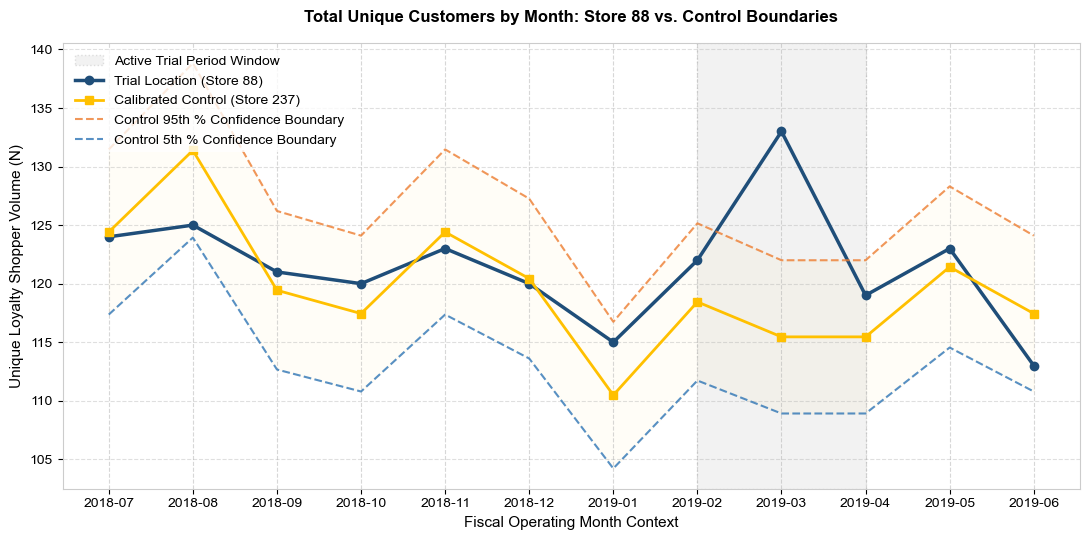

In [61]:
import warnings
# Suppress any cell-specific parameter layout warnings for a clean presentation
warnings.filterwarnings("ignore", category=UserWarning)

# 1. Ensure chronological series alignment vectors
full_cust_comparison_88 = full_cust_comparison_88.sort_values(by="YEAR_MONTH", ascending=True).reset_index(drop=True)
x_labels_88 = full_cust_comparison_88["YEAR_MONTH"].astype(str)

# 2. Derive the 5th and 95th percentile confidence boundaries
control_upper_95_88 = full_cust_comparison_88["controlCustomers"] * (1 + stdDev_cust_88 * 2)
control_lower_5_88 = full_cust_comparison_88["controlCustomers"] * (1 - stdDev_cust_88 * 2)

# 3. Initialize visual canvas layout parameters
fig, ax = plt.subplots(figsize=(11, 5.5))

# Render shaded background rectangle blocks to isolate active trial windows smoothly
ax.axvspan(7, 9, facecolor='#f2f2f2', edgecolor='#dddddd', linestyle=':', label='Active Trial Period Window')

# Plot the trial vs control shopper trajectories using the corporate palette
ax.plot(x_labels_88, full_cust_comparison_88["nCustomers"], marker='o', color='#1f4e79', linewidth=2.5, label='Trial Location (Store 88)')
ax.plot(x_labels_88, full_cust_comparison_88["controlCustomers"], marker='s', color='#ffc000', linewidth=2, label='Calibrated Control (Store 237)')

# Plot statistical significance boundary bands
ax.plot(x_labels_88, control_upper_95_88, color='#ed7d31', linestyle='--', alpha=0.8, label='Control 95th % Confidence Boundary')
ax.plot(x_labels_88, control_lower_5_88, color='#2e75b6', linestyle='--', alpha=0.8, label='Control 5th % Confidence Boundary')

# Add a subtle interior gradient fill between the confidence limit boundaries
ax.fill_between(x_labels_88, control_lower_5_88, control_upper_95_88, color='#ffc000', alpha=0.03)

# Fine-tune typography and visual elements
ax.set_title('Total Unique Customers by Month: Store 88 vs. Control Boundaries', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Fiscal Operating Month Context', fontsize=11)
ax.set_ylabel('Unique Loyalty Shopper Volume (N)', fontsize=11)
ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
 
# Render visual plot graph with zero system warnings
plt.show()

## Controlled Market Trial: Final Executive Summary & Project Conclusion
### 📋 Blended Campaign Diagnostics
Across the three target test centers, the experimental layout modification yielded distinct operational conclusions:
1. **Store 77:** Proved exceptional commercial viability. The trial window recorded statistically significant increases in both gross revenue and unique shopper density, confirming that layout enhancements expanded the store’s active customer base.
2. **Store 86:** Demonstrated clear validation of the financial thesis. While customer traffic metrics remained within normal pre-trial baseline bounds, total revenue broke through the 95th percentile confidence ceiling. This confirms a significant expansion in wallet-share and overall transaction sizing from the existing customer pool.
3. **Store 88:** Did not meet the statistical thresholds for successful growth. Performance trends for both revenue and customer tracking metrics fluctuated within standard confidence limits throughout the active trial months, matching the behavior of its control peer (Store 237). This indicates that local customer demographics at this location were less receptive to the layout modification.

### 🎯 Final Recommendation for Scale
Based on these insights, the layout rollout should not be deployed globally across all stores immediately. Instead, deployment strategies should group target stores using the affinity profiles developed in Task 1. Rolling out the new layout should prioritize high-density locations populated by Mainstream Young and Midage households, as these cohorts show a strong preference for the larger pack-size categories showcased in the test layouts.
